In [1]:
# Εργαλείο για τη διαχείριση διαδρομών και αρχείων
from pathlib import Path

# Βιβλιοθήκες επεξεργασίας και ανάλυσης δεδομένων
import numpy as np
import pandas as pd

# Βιβλιοθήκες δημιουργίας γραφημάτων
import matplotlib.pyplot as plt
import seaborn as sns

# Βασικές ρυθμίσεις εμφάνισης
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Οι βιβλιοθήκες φορτώθηκαν επιτυχώς.")

Οι βιβλιοθήκες φορτώθηκαν επιτυχώς.


# Μέρος 1: Ανάλυση ωριαίας ενεργειακής κατανάλωσης PJME

## 1. Φόρτωση και αρχικός έλεγχος του dataset

Σε αυτή την ενότητα φορτώνουμε το dataset `PJME_hourly.csv` και πραγματοποιούμε έναν πρώτο έλεγχο της δομής και του περιεχομένου του.

In [2]:
# Ορίζουμε τη διαδρομή του dataset
data_path = Path("../Datasets/PJME_hourly.csv")

# Ελέγχουμε ότι το αρχείο υπάρχει
if not data_path.exists():
    raise FileNotFoundError("Το αρχείο PJME_hourly.csv δεν βρέθηκε.")

# Φορτώνουμε το dataset
df = pd.read_csv(data_path)

print("Το dataset φορτώθηκε επιτυχώς.")
print(f"Αριθμός γραμμών: {df.shape[0]:,}")
print(f"Αριθμός στηλών: {df.shape[1]}")

# Εμφανίζουμε τις πρώτες πέντε γραμμές
df.head()

Το dataset φορτώθηκε επιτυχώς.
Αριθμός γραμμών: 145,366
Αριθμός στηλών: 2


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


## 2. Αρχικός έλεγχος των δεδομένων

Ελέγχουμε τις στήλες, τους τύπους δεδομένων, τις ελλιπείς τιμές και τις διπλές εγγραφές.

In [3]:
print("Στήλες του dataset:")
print(df.columns.tolist())

print("\nΤύποι δεδομένων:")
print(df.dtypes)

print("\nΕλλιπείς τιμές ανά στήλη:")
print(df.isna().sum())

print("\nΠλήρως διπλές γραμμές:")
print(df.duplicated().sum())

Στήλες του dataset:
['Datetime', 'PJME_MW']

Τύποι δεδομένων:
Datetime        str
PJME_MW     float64
dtype: object

Ελλιπείς τιμές ανά στήλη:
Datetime    0
PJME_MW     0
dtype: int64

Πλήρως διπλές γραμμές:
0


In [4]:
# Μετατρέπουμε τη στήλη Datetime σε μορφή ημερομηνίας
df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")

# Ταξινομούμε τις γραμμές χρονολογικά
df = df.sort_values("Datetime").reset_index(drop=True)

# Εμφανίζουμε τις ημερομηνίες σε μορφή ημέρα/μήνας/έτος
first_date = df["Datetime"].min().strftime("%d/%m/%Y")
last_date = df["Datetime"].max().strftime("%d/%m/%Y")

print("Πρώτη ημερομηνία:", first_date)
print("Τελευταία ημερομηνία:", last_date)
print("Μη έγκυρες ημερομηνίες:", df["Datetime"].isna().sum())

Πρώτη ημερομηνία: 01/01/2002
Τελευταία ημερομηνία: 03/08/2018
Μη έγκυρες ημερομηνίες: 0


In [5]:
print("Βασικά στατιστικά της ενεργειακής κατανάλωσης:")

df["PJME_MW"].describe()

Βασικά στατιστικά της ενεργειακής κατανάλωσης:


count    145366.000000
mean      32080.222831
std        6464.012166
min       14544.000000
25%       27573.000000
50%       31421.000000
75%       35650.000000
max       62009.000000
Name: PJME_MW, dtype: float64

## 3. Έλεγχος διπλών χρονικών στιγμών και χρονικών κενών

Επειδή το dataset περιέχει ωριαίες μετρήσεις, ελέγχουμε αν υπάρχουν ημερομηνίες που εμφανίζονται περισσότερες από μία φορές ή χρονικά διαστήματα μεγαλύτερα από μία ώρα.

In [6]:
# Ελέγχουμε πόσες χρονικές στιγμές εμφανίζονται ξανά
duplicate_times = df["Datetime"].duplicated().sum()

print("Διπλές χρονικές στιγμές:", duplicate_times)

# Εμφανίζουμε όλες τις σχετικές γραμμές
duplicates = df[df["Datetime"].duplicated(keep=False)]

duplicates

Διπλές χρονικές στιγμές: 4


,Datetime,PJME_MW
112487,2014-11-02 02:00:00,23755.0
112488,2014-11-02 02:00:00,22935.0
121223,2015-11-01 02:00:00,21567.0
121224,2015-11-01 02:00:00,21171.0
130127,2016-11-06 02:00:00,20795.0
130128,2016-11-06 02:00:00,21692.0
138863,2017-11-05 02:00:00,21236.0
138864,2017-11-05 02:00:00,20666.0


In [7]:
# Υπολογίζουμε τη χρονική διαφορά ανάμεσα σε διαδοχικές μετρήσεις
time_difference = df["Datetime"].diff()

# Εντοπίζουμε διαστήματα μεγαλύτερα από μία ώρα
gaps = df[time_difference > pd.Timedelta(hours=1)].copy()

print("Χρονικά κενά μεγαλύτερα από μία ώρα:", len(gaps))

gaps.head()

Χρονικά κενά μεγαλύτερα από μία ώρα: 30


,Datetime,PJME_MW
2306,2002-04-07 04:00:00,24487.0
7176,2002-10-27 03:00:00,20605.0
11040,2003-04-06 04:00:00,22902.0
15910,2003-10-26 03:00:00,20641.0
19774,2004-04-04 04:00:00,23208.0


## 4. Καθαρισμός της χρονικής σειράς

Οι διπλές χρονικές στιγμές συνδυάζονται χρησιμοποιώντας τη μέση ενεργειακή κατανάλωση. Στη συνέχεια δημιουργείται μια συνεχόμενη ωριαία χρονική σειρά και οι ώρες που λείπουν συμπληρώνονται με γραμμική παρεμβολή.

Με αυτόν τον τρόπο διατηρείται μία μέτρηση ανά ώρα, κάτι που είναι απαραίτητο για τις επόμενες χρονικές αναλύσεις.

In [8]:
# Κρατάμε αντίγραφο των αρχικών δεδομένων
df_original = df.copy()

# Συνδυάζουμε τις διπλές ώρες χρησιμοποιώντας τον μέσο όρο
df = (
    df.groupby("Datetime", as_index=False)["PJME_MW"]
    .mean()
    .sort_values("Datetime")
)

print("Διπλές χρονικές στιγμές μετά τη διόρθωση:")
print(df["Datetime"].duplicated().sum())

Διπλές χρονικές στιγμές μετά τη διόρθωση:
0


In [9]:
# Δημιουργούμε μία πλήρη ωριαία χρονική σειρά
full_time_range = pd.date_range(
    start=df["Datetime"].min(),
    end=df["Datetime"].max(),
    freq="h"
)

# Προσθέτουμε τις ώρες που λείπουν
df = df.set_index("Datetime").reindex(full_time_range)
df.index.name = "Datetime"

missing_hours = df["PJME_MW"].isna().sum()
print("Ώρες που χρειάζονται συμπλήρωση:", missing_hours)

# Συμπληρώνουμε τις τιμές με γραμμική παρεμβολή
df["PJME_MW"] = df["PJME_MW"].interpolate(method="time")

# Επαναφέρουμε την ημερομηνία ως κανονική στήλη
df = df.reset_index()

print("Ελλιπείς τιμές μετά τον καθαρισμό:")
print(df.isna().sum())

Ώρες που χρειάζονται συμπλήρωση: 30
Ελλιπείς τιμές μετά τον καθαρισμό:
Datetime    0
PJME_MW     0
dtype: int64


In [10]:
# Κρατάμε την πλήρη ωριαία σειρά για πιθανή μεταγενέστερη χρήση
df_continuous = df.copy()

# Επαναφέρουμε τις αρχικές γραμμές του dataset
df = df_original.copy()

print("Γραμμές αρχικού dataset:", len(df))
print("Γραμμές συνεχόμενης χρονικής σειράς:", len(df_continuous))

Γραμμές αρχικού dataset: 145366
Γραμμές συνεχόμενης χρονικής σειράς: 145392


## 5. Δημιουργία συνθετικών κατηγοριών πελατών

Το αρχικό dataset δεν περιέχει πραγματικές κατηγορίες πελατών. Για τις ανάγκες της εργασίας δημιουργείται η μεταβλητή `Customer_Segment` με βάση το student ID.

Οι κατηγορίες `Commercial`, `Residential` και `Industrial` είναι συνθετικές και δεν αντιπροσωπεύουν πραγματικούς πελάτες του αρχικού dataset.

In [11]:
def allocate_customer_segments(df, student_id):
    """
    Δημιουργεί τρεις συνθετικές κατηγορίες πελατών.
    Η κατανομή τους εξαρτάται από το student ID.
    """

    # Υπολογίζουμε μια μικρή μεταβολή με βάση το student ID
    drift = ((student_id % 5) - 2) * 0.05

    # Υπολογίζουμε την πιθανότητα κάθε κατηγορίας
    prob_commercial = 0.40 + drift
    prob_residential = 0.35 - drift
    prob_industrial = 1.0 - (
        prob_commercial + prob_residential
    )

    # Αποθηκεύουμε τις πιθανότητες με τη σειρά των κατηγοριών
    weights = [
        prob_commercial,
        prob_residential,
        prob_industrial
    ]

    # Ορίζουμε τις τρεις συνθετικές κατηγορίες πελατών
    categories = [
        'Commercial',
        'Residential',
        'Industrial'
    ]

    # Χρησιμοποιούμε το student ID ώστε τα αποτελέσματα
    # να είναι ίδια κάθε φορά που εκτελείται ο κώδικας
    np.random.seed(student_id)

    # Αντιστοιχίζουμε κάθε γραμμή σε μία κατηγορία πελάτη
    df['Customer_Segment'] = np.random.choice(
        categories,
        size=len(df),
        p=weights
    )

    # Εμφανίζουμε την ποσοστιαία κατανομή των κατηγοριών
    print(
        f"\nΚατανομή κατηγοριών πελατών "
        f"για το ID {student_id}:"
    )

    print(
        df['Customer_Segment']
        .value_counts(normalize=True)
        .round(3) * 100
    )

    return df

In [12]:
# Ορίζουμε το αριθμητικό μέρος του student ID
student_id = 29901
S = student_id

# Εφαρμόζουμε τη συνάρτηση στο dataset
df = allocate_customer_segments(df, student_id)

# Εμφανίζουμε τις πρώτες γραμμές με τη νέα στήλη
df.head()


Κατανομή κατηγοριών πελατών για το ID 29901:
Customer_Segment
Residential    40.0
Commercial     34.9
Industrial     25.1
Name: proportion, dtype: float64


,Datetime,PJME_MW,Customer_Segment
0,2002-01-01 01:00:00,30393.0,Residential
1,2002-01-01 02:00:00,29265.0,Residential
2,2002-01-01 03:00:00,28357.0,Commercial
3,2002-01-01 04:00:00,27899.0,Commercial
4,2002-01-01 05:00:00,28057.0,Industrial


## 6. Δημιουργία χρονικών χαρακτηριστικών

Από τη στήλη `Datetime` δημιουργούμε βασικά χρονικά χαρακτηριστικά που θα χρησιμοποιηθούν στις επόμενες αναλύσεις.

Επιπλέον, δημιουργούμε τα κυκλικά χαρακτηριστικά `Month_sin` και `Month_cos` σύμφωνα με τους μαθηματικούς τύπους του handbook. Τα χαρακτηριστικά αυτά αποτυπώνουν την κυκλική φύση των μηνών, όπου ο Δεκέμβριος βρίσκεται χρονικά κοντά στον Ιανουάριο.

In [13]:
# Παίρνουμε τον μήνα και την ώρα από τη στήλη Datetime
df['t_month'] = df['Datetime'].dt.month
df['t_hour'] = df['Datetime'].dt.hour

# Εφαρμόζουμε τους τύπους του handbook
df['Month_sin'] = np.sin(
    2 * np.pi * df['t_month'] / 12
) * 3

df['Month_cos'] = np.cos(
    2 * np.pi * df['t_month'] / 12
) * 2

# Ελέγχουμε τα νέα χαρακτηριστικά
df[
    ['Datetime', 't_month', 't_hour', 'Month_sin', 'Month_cos']
].head()

,Datetime,t_month,t_hour,Month_sin,Month_cos
0,2002-01-01 01:00:00,1,1,1.5,1.732051
1,2002-01-01 02:00:00,1,2,1.5,1.732051
2,2002-01-01 03:00:00,1,3,1.5,1.732051
3,2002-01-01 04:00:00,1,4,1.5,1.732051
4,2002-01-01 05:00:00,1,5,1.5,1.732051


In [14]:
# Υπολογίζουμε τις παραμέτρους από το student ID
alpha_s = 15 + (S % 7) - 3  # Ετήσια μέση θερμοκρασίας βάσης
beta_s = 12 + (S % 5) * 0.5  # Εύρος εποχικής διακύμασης της θερμοκρασίας μεταξύ καλοκαιριού και χειμώνα
gamma = 5  # Εύρος ημερίσιας μεταβολής της θερμοκρασίας

phi_s1 = 5 + (S % 4)  # Μετατοπίσεις φάσης ώστε η μέγιστη θερμοκρασία να συμπίπτει με 
phi_s2 = 6 + (S % 4)  # αργά το απόγευμα και τα μέσα του καλοκαιριού

print("alpha_s:", alpha_s)
print("beta_s:", beta_s)
print("gamma:", gamma)
print("phi_s1:", phi_s1)
print("phi_s2:", phi_s2)

alpha_s: 16
beta_s: 12.5
gamma: 5
phi_s1: 6
phi_s2: 7


### Παραδοχές για τη συνθετική θερμοκρασία

Η `Synthetic_Temperature` δεν προέρχεται από πραγματικές μετεωρολογικές μετρήσεις. Είναι μια συνθετική μεταβλητή που δημιουργείται για τις ανάγκες της εργασίας, με βάση τον μήνα, την ώρα και το φοιτητικό ID.

Για τους υπολογισμούς χρησιμοποιείται το αριθμητικό μέρος του φοιτητικού ID:

- `student_id = 29901`
- `S = student_id`

Από αυτό προκύπτουν οι ακόλουθες προσωπικές παράμετροι:

- `alpha_s = 16`: η βασική μέση θερμοκρασία
- `beta_s = 12.5`: το μέγεθος της εποχικής μεταβολής
- `gamma = 5`: το μέγεθος της ημερήσιας μεταβολής
- `phi_s1 = 6`: η μετατόπιση της εποχικής καμπύλης
- `phi_s2 = 7`: η μετατόπιση της ημερήσιας καμπύλης

Ο τύπος που δίνεται στο εγχειρίδιο παρουσιάζει ορισμένες ασάφειες. Για τον λόγο αυτό έγιναν οι παρακάτω παραδοχές:

1. Η `alpha_s` προστίθεται στη θερμοκρασία, επειδή περιγράφεται ως βασική μέση θερμοκρασία.

2. Στον ημερήσιο όρο χρησιμοποιείται η `t_hour` και όχι η `t_month`, ώστε η θερμοκρασία να μεταβάλλεται μέσα στην ημέρα.

3. Χρησιμοποιείται η `gamma` ως πλάτος της ημερήσιας μεταβολής, χωρίς επιπλέον πολλαπλασιασμό επί 2, επειδή η ίδια περιγράφεται ήδη ως το πλάτος αυτής της μεταβολής.

4. Επειδή το εγχειρίδιο δεν δίνει τις παραμέτρους του τυχαίου σφάλματος, θεωρούμε ότι:

   $e \sim N(0,1)$

   Δηλαδή, το σφάλμα έχει μέση τιμή 0 και τυπική απόκλιση 1.

5. Το `S`, το οποίο είναι ίσο με το `student_id`, χρησιμοποιείται ως seed. Έτσι, οι ίδιες τυχαίες τιμές παράγονται κάθε φορά που εκτελείται το notebook και τα αποτελέσματα μπορούν να αναπαραχθούν.

Με βάση αυτές τις παραδοχές, η βασική θερμοκρασία υπολογίζεται ως:

$$
T_{base} =
\alpha_s +
\beta_s \sin\left(\frac{2\pi(t_{month}-\phi_{s1})}{12}\right) +
\gamma \sin\left(\frac{2\pi(t_{hour}-\phi_{s2})}{24}\right)
$$

Στη συνέχεια, προσθέτουμε το τυχαίο σφάλμα:

$$
Synthetic\_Temperature = T_{base} + e
$$

Η `T_base` δείχνει την εποχική και ημερήσια μεταβολή που δημιουργεί ο μαθηματικός τύπος, ενώ η `Synthetic_Temperature` περιλαμβάνει και μια μικρή τυχαία διαφοροποίηση.

Η μεταβλητή αυτή δεν πρέπει να παρουσιάζεται ως πραγματική θερμοκρασία ούτε να χρησιμοποιείται για να αποδείξει αιτιώδη σχέση μεταξύ θερμοκρασίας και ενεργειακής ζήτησης. Τα μοτίβα της έχουν δημιουργηθεί τεχνητά από τον παραπάνω τύπο.

In [15]:
# Χρησιμοποιούμε το student ID ως seed,
# ώστε το σφάλμα να είναι ίδιο σε κάθε εκτέλεση
np.random.seed(S)

# Δημιουργούμε το τυχαίο σφάλμα με την παραδοχή N(0, 1)
e = np.random.normal(
    loc=0,
    scale=1,
    size=len(df)
)

# Υπολογίζουμε πρώτα τη βασική συνθετική θερμοκρασία
df['T_base'] = (
    alpha_s
    + beta_s
    * np.sin(
        2 * np.pi * (df['t_month'] - phi_s1) / 12
    )
    + gamma
    * np.sin(
        2 * np.pi * (df['t_hour'] - phi_s2) / 24
    )
)

# Προσθέτουμε το τυχαίο σφάλμα
df['Synthetic_Temperature'] = df['T_base'] + e

# Εμφανίζουμε τις πρώτες τιμές
df[
    [
        'Datetime',
        't_month',
        't_hour',
        'T_base',
        'Synthetic_Temperature'
    ]
].head(20)

,Datetime,t_month,t_hour,T_base,Synthetic_Temperature
0,2002-01-01 01:00:00,1,1,4.750000,4.908232
1,2002-01-01 02:00:00,1,2,4.920371,6.981854
2,2002-01-01 03:00:00,1,3,5.419873,5.184121
3,2002-01-01 04:00:00,1,4,6.214466,5.880744
4,2002-01-01 05:00:00,1,5,7.250000,7.939935
5,2002-01-01 06:00:00,1,6,8.455905,9.076163
6,2002-01-01 07:00:00,1,7,9.750000,9.098643
7,2002-01-01 08:00:00,1,8,11.044095,11.776639
8,2002-01-01 09:00:00,1,9,12.250000,12.121279
9,2002-01-01 10:00:00,1,10,13.285534,13.210497


In [16]:
# Ελέγχουμε τις βασικές πληροφορίες των δύο νέων μεταβλητών
df[['T_base', 'Synthetic_Temperature']].describe().round(2)

,T_base,Synthetic_Temperature
count,145366.00,145366.00
mean,15.86,15.87
std,9.49,9.54
min,-1.50,-4.90
25%,7.83,7.81
50%,14.75,15.66
75%,23.67,23.92
max,33.50,36.80


In [17]:
# Ελέγχουμε αν υπάρχουν ελλιπείς τιμές
df[['T_base', 'Synthetic_Temperature']].isna().sum()

T_base                   0
Synthetic_Temperature    0
dtype: int64

## 6. Part 1a: Energy Demand Profiling and Operational Segmentation

### 6.1 Client Baseline Consumption Profile

Αρχικά δημιουργούμε ένα βασικό προφίλ κατανάλωσης για κάθε συνθετική κατηγορία πελατών. Υπολογίζουμε τη μέση τιμή και τη διάμεσο, ώστε να εξετάσουμε την τυπική κατανάλωση, καθώς και την τυπική απόκλιση, ώστε να μετρήσουμε τη μεταβλητότητα της ενεργειακής ζήτησης. Τέλος, υπολογίζουμε την ελάχιστη και τη μέγιστη τιμή για να εντοπίσουμε τα ιστορικά όρια κατανάλωσης.

In [18]:
# Υπολογίζουμε το βασικό προφίλ κατανάλωσης
# για κάθε συνθετική κατηγορία πελατών
client_baseline_profile = (
    df.groupby('Customer_Segment')
    .agg(
        Mean_PJME_MW=('PJME_MW', 'mean'),
        Median_PJME_MW=('PJME_MW', 'median'),
        Standard_Deviation_PJME_MW=('PJME_MW', 'std'),
        Minimum_PJME_MW=('PJME_MW', 'min'),
        Maximum_PJME_MW=('PJME_MW', 'max')
    )
    .round(2)
)

client_baseline_profile

,Mean_PJME_MW,Median_PJME_MW,Standard_Deviation_PJME_MW,Minimum_PJME_MW,Maximum_PJME_MW
Customer_Segment,,,,,
Commercial,32092.17,31424.0,6476.64,14544.0,61770.0
Industrial,32085.64,31416.5,6448.09,17734.0,61909.0
Residential,32066.38,31422.0,6463.05,14586.0,62009.0


#### Ερμηνεία αποτελεσμάτων

Οι τρεις συνθετικές κατηγορίες πελατών παρουσιάζουν πολύ παρόμοιο βασικό προφίλ ενεργειακής ζήτησης.

Η Commercial κατηγορία έχει την υψηλότερη μέση ζήτηση, με 32.092,17 MW, και ακολουθούν η Industrial με 32.085,64 MW και η Residential με 32.066,38 MW. Οι διαφορές μεταξύ των μέσων τιμών είναι πολύ μικρές.

Οι διάμεσοι βρίσκονται περίπου στις 31.400 MW και στις τρεις κατηγορίες. Επειδή οι μέσες τιμές είναι υψηλότερες από τις αντίστοιχες διαμέσους, φαίνεται ότι ορισμένες περίοδοι ιδιαίτερα υψηλής ζήτησης επηρεάζουν προς τα πάνω τον μέσο όρο.

Η τυπική απόκλιση είναι περίπου 6.450 MW σε όλες τις κατηγορίες, γεγονός που δείχνει παρόμοιο επίπεδο μεταβλητότητας στην ενεργειακή ζήτηση. Η Commercial κατηγορία παρουσιάζει οριακά τη μεγαλύτερη μεταβλητότητα, με τυπική απόκλιση 6.476,64 MW.

Η χαμηλότερη τιμή εμφανίζεται στην Commercial κατηγορία και είναι 14.544 MW, ενώ η υψηλότερη εμφανίζεται στη Residential κατηγορία και είναι 62.009 MW.

Οι μικρές διαφορές μεταξύ των κατηγοριών είναι αναμενόμενες, επειδή το `Customer_Segment` δημιουργήθηκε με τυχαία κατανομή και δεν βασίζεται σε πραγματικά χαρακτηριστικά ή συμπεριφορές πελατών. Επομένως, τα αποτελέσματα δεν πρέπει να ερμηνευτούν ως πραγματικές διαφορές μεταξύ οικιακών, εμπορικών και βιομηχανικών καταναλωτών.

### 6.2 Hourly System Demands

Σε αυτή την ενότητα εξετάζουμε τον πλήρη 24ωρο κύκλο του ηλεκτρικού δικτύου. Για κάθε ώρα, από τις `00:00` έως τις `23:00`, υπολογίζουμε τη μέση τιμή του `PJME_MW` χρησιμοποιώντας όλες τις διαθέσιμες ιστορικές παρατηρήσεις.

Για να εντοπίσουμε την εντονότερη πρωινή αύξηση, υπολογίζουμε τη διαφορά της μέσης ζήτησης κάθε ώρας από την αμέσως προηγούμενη. Ως πρωινή περίοδο ορίζουμε το χρονικό διάστημα από τις `05:00` έως τις `12:00`.

Για τον εντοπισμό της απογευματινής αιχμής εξετάζουμε το χρονικό διάστημα από τις `15:00` έως τις `19:00` και βρίσκουμε την ώρα με την υψηλότερη μέση ενεργειακή ζήτηση.

Οι συγκεκριμένες χρονικές περίοδοι χρησιμοποιούνται ως λειτουργικές παραδοχές, επειδή το εγχειρίδιο αναφέρεται σε πρωινές αυξήσεις και απογευματινές αιχμές χωρίς να ορίζει συγκεκριμένα ωριαία όρια.

Αριθμός ωρών στο διάγραμμα: 24
Μεγαλύτερη πρωινή αύξηση: 07:00 (2448.19 MW)
Υψηλότερη απογευματινή ζήτηση: 19:00 (36426.63 MW)


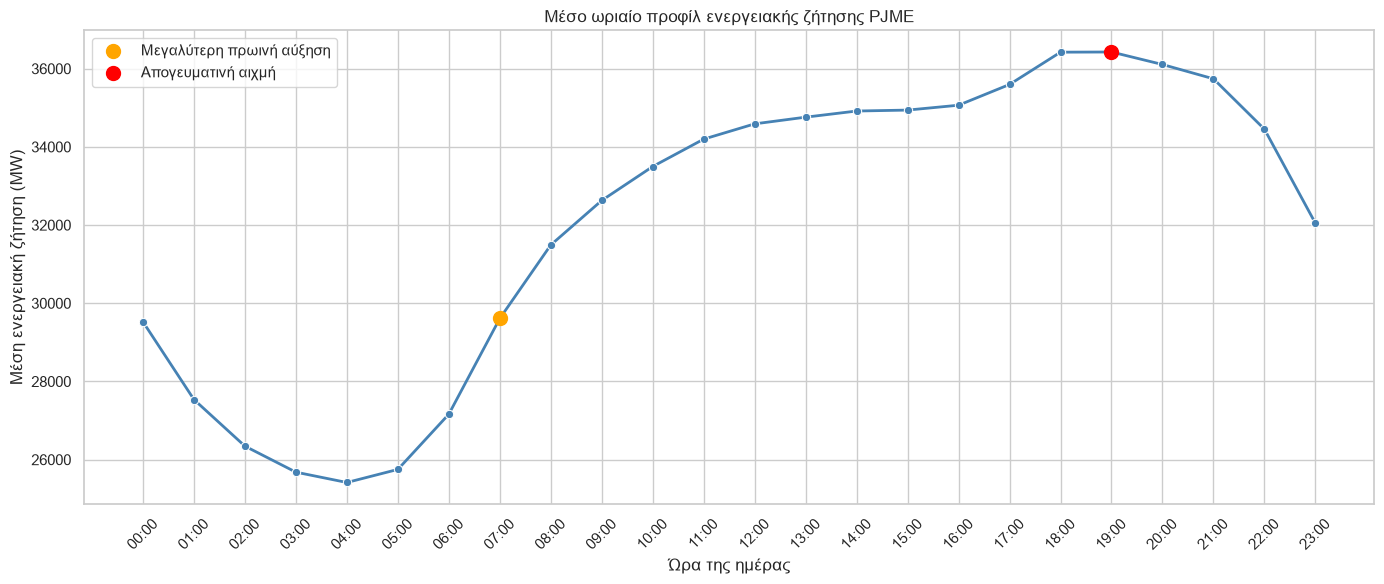

In [19]:
# Υπολογίζουμε τη μέση ζήτηση για κάθε ώρα
# χρησιμοποιώντας όλες τις ιστορικές παρατηρήσεις
hourly_profile = (
    df.groupby('t_hour', as_index=False)['PJME_MW']
    .mean()
)

# Υπολογίζουμε τη μεταβολή από την προηγούμενη ώρα
hourly_profile['Hourly_Change'] = (
    hourly_profile['PJME_MW'].diff()
)

# Ορίζουμε την πρωινή περίοδο από 05:00 έως 12:00
morning_profile = hourly_profile[
    hourly_profile['t_hour'].between(5, 12)
]

# Βρίσκουμε τη μεγαλύτερη πρωινή αύξηση
steepest_morning_ramp = morning_profile.loc[
    morning_profile['Hourly_Change'].idxmax()
]

# Ορίζουμε την απογευματινή περίοδο από 15:00 έως 19:00
late_afternoon_profile = hourly_profile[
    hourly_profile['t_hour'].between(15, 19)
]

# Βρίσκουμε την υψηλότερη απογευματινή ζήτηση
late_afternoon_peak = late_afternoon_profile.loc[
    late_afternoon_profile['PJME_MW'].idxmax()
]

print("Αριθμός ωρών στο διάγραμμα:",
      hourly_profile['t_hour'].nunique())

print(
    f"Μεγαλύτερη πρωινή αύξηση: "
    f"{int(steepest_morning_ramp['t_hour']):02d}:00 "
    f"({steepest_morning_ramp['Hourly_Change']:.2f} MW)"
)

print(
    f"Υψηλότερη απογευματινή ζήτηση: "
    f"{int(late_afternoon_peak['t_hour']):02d}:00 "
    f"({late_afternoon_peak['PJME_MW']:.2f} MW)"
)

# Δημιουργούμε το ωριαίο διάγραμμα
fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=hourly_profile,
    x='t_hour',
    y='PJME_MW',
    marker='o',
    linewidth=2,
    color='steelblue',
    ax=ax
)

# Επισημαίνουμε τη μεγαλύτερη πρωινή αύξηση
ax.scatter(
    steepest_morning_ramp['t_hour'],
    steepest_morning_ramp['PJME_MW'],
    color='orange',
    s=100,
    label='Μεγαλύτερη πρωινή αύξηση',
    zorder=3
)

# Επισημαίνουμε την απογευματινή αιχμή
ax.scatter(
    late_afternoon_peak['t_hour'],
    late_afternoon_peak['PJME_MW'],
    color='red',
    s=100,
    label='Απογευματινή αιχμή',
    zorder=3
)

ax.set_title('Μέσο ωριαίο προφίλ ενεργειακής ζήτησης PJME')
ax.set_xlabel('Ώρα της ημέρας')
ax.set_ylabel('Μέση ενεργειακή ζήτηση (MW)')

# Εμφανίζουμε και τις 24 ώρες
ax.set_xticks(range(24))
ax.set_xticklabels(
    [f'{hour:02d}:00' for hour in range(24)],
    rotation=45
)

ax.legend()

plt.tight_layout()
plt.show()

#### Αποτελέσματα ωριαίου προφίλ

Το ωριαίο διάγραμμα δείχνει έναν ξεκάθαρο ημερήσιο κύκλο στην ενεργειακή ζήτηση.

Κατά τη διάρκεια της νύχτας η ζήτηση μειώνεται σταδιακά και φτάνει στη χαμηλότερη περιοχή της περίπου στις `04:00`. Από τις πρώτες πρωινές ώρες αρχίζει να αυξάνεται ξανά.

Η μεγαλύτερη πρωινή αύξηση καταγράφεται στις `07:00`, όταν η μέση ζήτηση αυξάνεται κατά 2.448,19 MW σε σχέση με την προηγούμενη ώρα. Η έντονη αυτή άνοδος μπορεί να συνδέεται με την έναρξη της καθημερινής οικιακής, εμπορικής και βιομηχανικής δραστηριότητας.

Μετά την πρωινή αύξηση, η ζήτηση συνεχίζει να ανεβαίνει με πιο σταθερό ρυθμό και παραμένει υψηλή κατά τη διάρκεια της ημέρας. Μία δεύτερη άνοδος εμφανίζεται αργά το απόγευμα.

Η υψηλότερη μέση ζήτηση καταγράφεται στις `19:00` και φτάνει τα 36.426,63 MW. Μετά τη βραδινή αιχμή, η ζήτηση αρχίζει να μειώνεται καθώς περιορίζεται σταδιακά η καθημερινή δραστηριότητα.

Το συνολικό μοτίβο δείχνει ότι η ζήτηση του δικτύου επηρεάζεται έντονα από τον καθημερινό κύκλο ανθρώπινης δραστηριότητας. Ωστόσο, επειδή το dataset περιέχει μόνο τις τιμές του `PJME_MW`, οι παραπάνω συνδέσεις αποτελούν λογικές ερμηνείες και όχι απόδειξη αιτιώδους σχέσης.

### 6.3 Weekly & Monthly Operational Cycles

Σε αυτή την ενότητα εξετάζουμε πώς μεταβάλλεται η ενεργειακή ζήτηση μέσα στην εβδομάδα και κατά τη διάρκεια του έτους.

Στο πρώτο διάγραμμα υπολογίζουμε τη μέση ζήτηση για κάθε ημέρα, από τη Δευτέρα έως την Κυριακή. Με αυτόν τον τρόπο μπορούμε να δούμε αν υπάρχει διαφορετική συμπεριφορά μεταξύ εργάσιμων ημερών και Σαββατοκύριακου.

Στο δεύτερο διάγραμμα υπολογίζουμε τη μέση ζήτηση για κάθε μήνα, από τον Ιανουάριο έως τον Δεκέμβριο. Έτσι μπορούμε να εντοπίσουμε πιθανές εποχικές μεταβολές στην κατανάλωση ενέργειας.

Και στις δύο περιπτώσεις χρησιμοποιούνται όλες οι διαθέσιμες ιστορικές παρατηρήσεις του dataset.

Ημέρα με την υψηλότερη μέση ζήτηση: Τρίτη (33272.27 MW)
Ημέρα με τη χαμηλότερη μέση ζήτηση: Κυριακή (29411.87 MW)
Μήνας με την υψηλότερη μέση ζήτηση: Ιούλιος (37881.97 MW)
Μήνας με τη χαμηλότερη μέση ζήτηση: Απρίλιος (27863.34 MW)


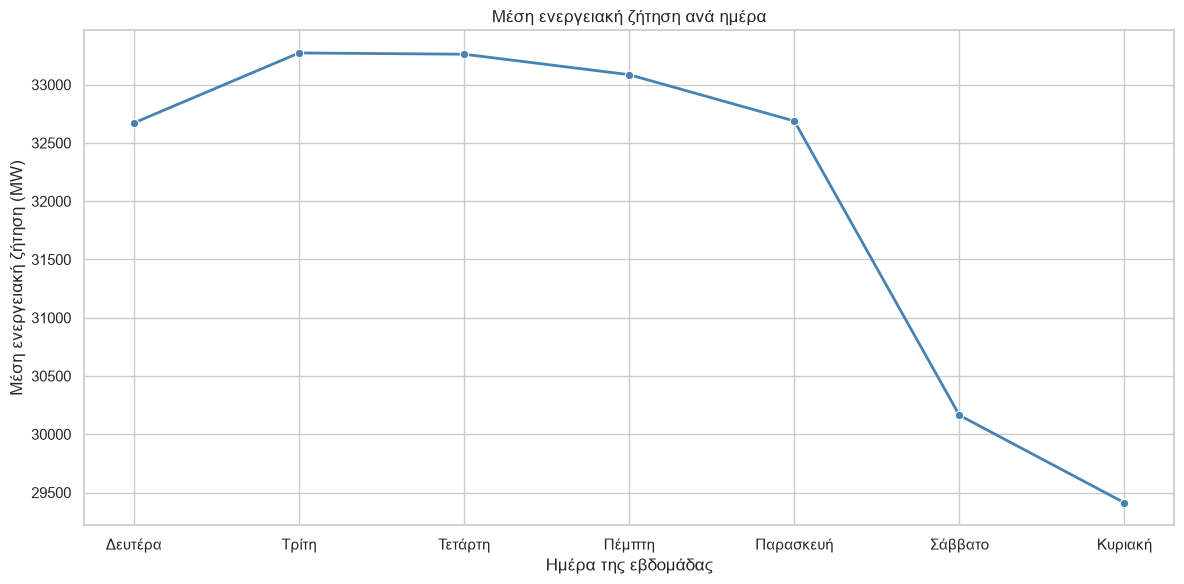

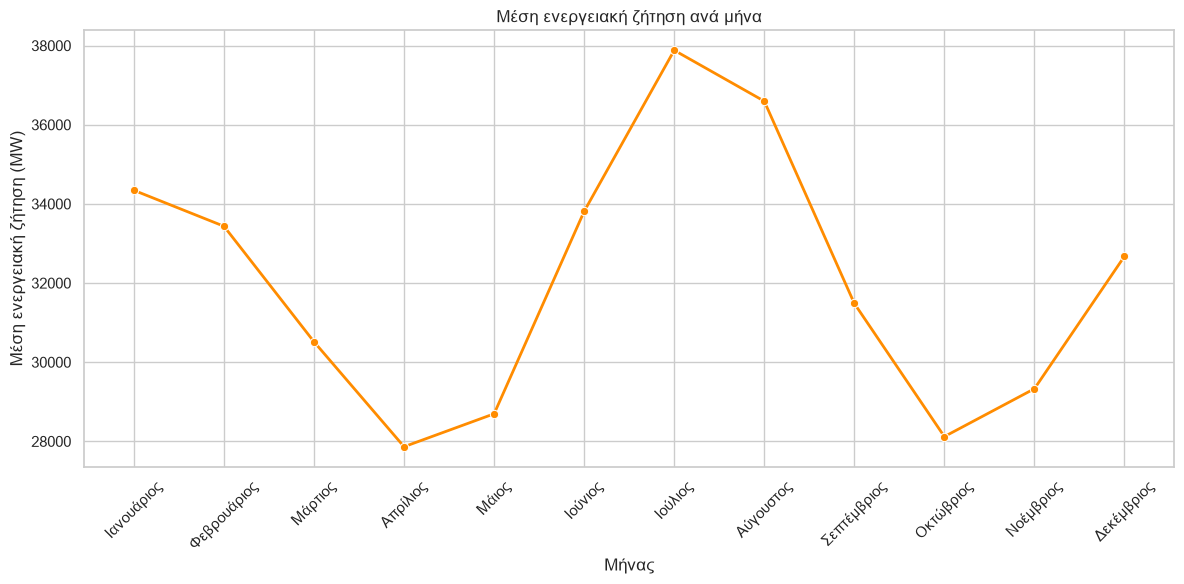

In [20]:
# Δημιουργούμε τον αριθμό της ημέρας
# Δευτέρα = 0 και Κυριακή = 6
df['Day_Number'] = df['Datetime'].dt.dayofweek

# Ονόματα ημερών
day_names = [
    'Δευτέρα',
    'Τρίτη',
    'Τετάρτη',
    'Πέμπτη',
    'Παρασκευή',
    'Σάββατο',
    'Κυριακή'
]

# Ονόματα μηνών
month_names = [
    'Ιανουάριος',
    'Φεβρουάριος',
    'Μάρτιος',
    'Απρίλιος',
    'Μάιος',
    'Ιούνιος',
    'Ιούλιος',
    'Αύγουστος',
    'Σεπτέμβριος',
    'Οκτώβριος',
    'Νοέμβριος',
    'Δεκέμβριος'
]

# Υπολογίζουμε τη μέση ζήτηση για κάθε ημέρα
weekly_profile = (
    df.groupby('Day_Number')['PJME_MW']
    .mean()
    .reindex(range(7))
    .reset_index()
)

# Υπολογίζουμε τη μέση ζήτηση για κάθε μήνα
monthly_profile = (
    df.groupby('t_month')['PJME_MW']
    .mean()
    .reindex(range(1, 13))
    .reset_index()
)

# Βρίσκουμε την ημέρα με την υψηλότερη και τη χαμηλότερη ζήτηση
highest_day = weekly_profile.loc[
    weekly_profile['PJME_MW'].idxmax()
]

lowest_day = weekly_profile.loc[
    weekly_profile['PJME_MW'].idxmin()
]

# Βρίσκουμε τον μήνα με την υψηλότερη και τη χαμηλότερη ζήτηση
highest_month = monthly_profile.loc[
    monthly_profile['PJME_MW'].idxmax()
]

lowest_month = monthly_profile.loc[
    monthly_profile['PJME_MW'].idxmin()
]

# Εμφανίζουμε τα βασικά αποτελέσματα
print(
    f"Ημέρα με την υψηλότερη μέση ζήτηση: "
    f"{day_names[int(highest_day['Day_Number'])]} "
    f"({highest_day['PJME_MW']:.2f} MW)"
)

print(
    f"Ημέρα με τη χαμηλότερη μέση ζήτηση: "
    f"{day_names[int(lowest_day['Day_Number'])]} "
    f"({lowest_day['PJME_MW']:.2f} MW)"
)

print(
    f"Μήνας με την υψηλότερη μέση ζήτηση: "
    f"{month_names[int(highest_month['t_month']) - 1]} "
    f"({highest_month['PJME_MW']:.2f} MW)"
)

print(
    f"Μήνας με τη χαμηλότερη μέση ζήτηση: "
    f"{month_names[int(lowest_month['t_month']) - 1]} "
    f"({lowest_month['PJME_MW']:.2f} MW)"
)

# Πρώτο διάγραμμα: εβδομαδιαίο προφίλ
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=weekly_profile,
    x='Day_Number',
    y='PJME_MW',
    marker='o',
    linewidth=2,
    color='steelblue'
)

plt.title('Μέση ενεργειακή ζήτηση ανά ημέρα')
plt.xlabel('Ημέρα της εβδομάδας')
plt.ylabel('Μέση ενεργειακή ζήτηση (MW)')

plt.xticks(
    range(7),
    day_names
)

plt.tight_layout()
plt.show()

# Δεύτερο διάγραμμα: μηνιαίο προφίλ
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_profile,
    x='t_month',
    y='PJME_MW',
    marker='o',
    linewidth=2,
    color='darkorange'
)

plt.title('Μέση ενεργειακή ζήτηση ανά μήνα')
plt.xlabel('Μήνας')
plt.ylabel('Μέση ενεργειακή ζήτηση (MW)')

plt.xticks(
    range(1, 13),
    month_names,
    rotation=45
)

plt.tight_layout()
plt.show()

#### Αποτελέσματα εβδομαδιαίου και μηνιαίου κύκλου

Στο εβδομαδιαίο διάγραμμα παρατηρούμε ότι η ζήτηση παραμένει σχετικά υψηλή κατά τις εργάσιμες ημέρες. Η υψηλότερη μέση τιμή εμφανίζεται την Τρίτη και φτάνει τα 33.272,27 MW.

Από την Παρασκευή και μετά αρχίζει να μειώνεται, ενώ το Σαββατοκύριακο η πτώση γίνεται πολύ πιο έντονη. Η Κυριακή παρουσιάζει τη χαμηλότερη μέση ζήτηση, με 29.411,87 MW. Η διαφορά ανάμεσα στην Τρίτη και την Κυριακή είναι περίπου 3.860 MW.

Το συγκεκριμένο μοτίβο δείχνει ότι η ζήτηση είναι μεγαλύτερη κατά τη διάρκεια της εργάσιμης εβδομάδας και μειώνεται όταν περιορίζεται η εμπορική και βιομηχανική δραστηριότητα. Ωστόσο, το dataset δεν περιλαμβάνει άμεσες πληροφορίες για τις δραστηριότητες των καταναλωτών, επομένως αυτή αποτελεί μια λογική ερμηνεία του μοτίβου και όχι απόδειξη αιτιώδους σχέσης.

Στο μηνιαίο διάγραμμα εμφανίζεται έντονη εποχικότητα. Η ζήτηση μειώνεται από τον Ιανουάριο μέχρι τον Απρίλιο, ο οποίος παρουσιάζει τη χαμηλότερη μέση τιμή με 27.863,34 MW. Στη συνέχεια αυξάνεται σημαντικά και φτάνει στη μεγαλύτερη τιμή της τον Ιούλιο, με 37.881,97 MW.

Μετά τον Αύγουστο η ζήτηση μειώνεται ξανά, πριν αρχίσει να ανεβαίνει προς τον Δεκέμβριο. Η αυξημένη ζήτηση κατά τους θερινούς και τους χειμερινούς μήνες μπορεί να συνδέεται με μεγαλύτερες ανάγκες για ψύξη και θέρμανση. Αντίθετα, οι ηπιότεροι μήνες της άνοιξης και του φθινοπώρου παρουσιάζουν χαμηλότερη μέση ζήτηση.

Τα αποτελέσματα δείχνουν ότι τόσο ο εβδομαδιαίος κύκλος εργασίας όσο και η εποχικότητα συνδέονται με σημαντικές μεταβολές στη ζήτηση του δικτύου.

### 6.4 Thermal Meteorological Splits

Σε αυτή την ενότητα επιλέγουμε ένα πλήρες λειτουργικό έτος και συγκρίνουμε το ωριαίο προφίλ της ενεργειακής ζήτησης ανάμεσα στις δύο εποχικές περιόδους που ορίζει η εργασία.

Το λειτουργικό έτος ξεκινά την 1η Νοεμβρίου 2011 και ολοκληρώνεται στις 31 Οκτωβρίου 2012. Επιλέγουμε αυτή την περίοδο ώστε να έχουμε έναν συνεχόμενο κύκλο δώδεκα μηνών, ο οποίος περιλαμβάνει μία πλήρη χειμερινή και μία πλήρη θερινή περίοδο.

Οι δύο περίοδοι ορίζονται ως εξής:

- **Winter Peak:** Νοέμβριος έως Απρίλιος
- **Summer Peak:** Μάιος έως Οκτώβριος

Για κάθε περίοδο υπολογίζουμε τη μέση ενεργειακή ζήτηση ανά ώρα, ώστε να συγκρίνουμε το σχήμα της κατανάλωσης μέσα στο 24ωρο.

Περίοδος: 01/11/2011 - 30/10/2012
Συνολικές ώρες: 8760

Ώρες ανά εποχή:
Season
Summer Peak    4392
Winter Peak    4368
Name: count, dtype: int64
Summer Peak — ώρα αιχμής: 17:00 (38733.69 MW)
Winter Peak — ώρα αιχμής: 19:00 (33578.46 MW)


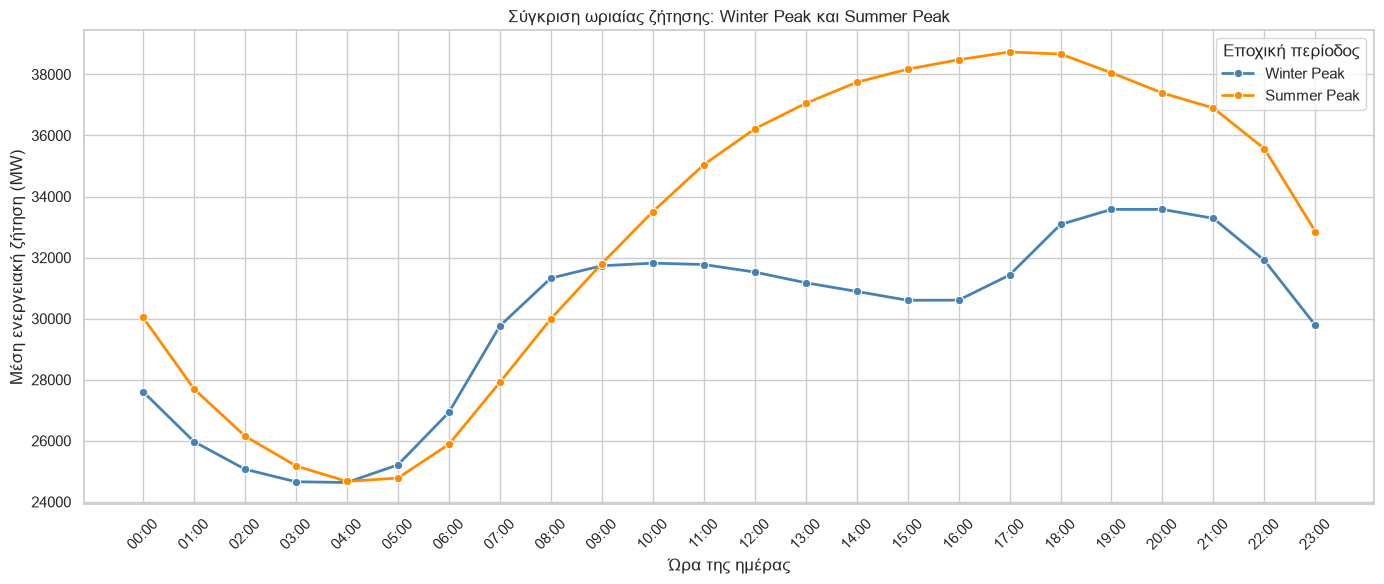

In [58]:
# Επιλέγουμε ένα συνεχόμενο λειτουργικό έτος
operational_year = df_continuous[
    (df_continuous['Datetime'] >= '2011-11-01') &
    (df_continuous['Datetime'] < '2012-10-31')
].copy()

# Δημιουργούμε την ώρα και τον μήνα
operational_year['Hour'] = (
    operational_year['Datetime'].dt.hour
)

operational_year['Month'] = (
    operational_year['Datetime'].dt.month
)

# Χωρίζουμε τις παρατηρήσεις σε χειμερινή και θερινή περίοδο
operational_year['Season'] = np.where(
    operational_year['Month'].isin([11, 12, 1, 2, 3, 4]),
    'Winter Peak',
    'Summer Peak'
)

# Υπολογίζουμε τη μέση ζήτηση ανά ώρα και εποχή
seasonal_profile = (
    operational_year
    .groupby(['Season', 'Hour'], as_index=False)['PJME_MW']
    .mean()
)

# Ελέγχουμε την περίοδο και το πλήθος των ωρών
print(
    "Περίοδος:",
    operational_year['Datetime'].min().strftime('%d/%m/%Y'),
    "-",
    operational_year['Datetime'].max().strftime('%d/%m/%Y')
)

print("Συνολικές ώρες:", len(operational_year))

print(
    "\nΏρες ανά εποχή:"
)

print(
    operational_year['Season'].value_counts()
)

# Βρίσκουμε την ώρα αιχμής κάθε εποχής
seasonal_peaks = seasonal_profile.loc[
    seasonal_profile.groupby('Season')['PJME_MW'].idxmax()
]

for _, row in seasonal_peaks.iterrows():
    print(
        f"{row['Season']} — ώρα αιχμής: "
        f"{int(row['Hour']):02d}:00 "
        f"({row['PJME_MW']:.2f} MW)"
    )

# Συγκρίνουμε τα δύο ωριαία προφίλ
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=seasonal_profile,
    x='Hour',
    y='PJME_MW',
    hue='Season',
    hue_order=['Winter Peak', 'Summer Peak'],
    palette={
        'Winter Peak': 'steelblue',
        'Summer Peak': 'darkorange'
    },
    marker='o',
    linewidth=2
)

plt.title(
    'Σύγκριση ωριαίας ζήτησης: Winter Peak και Summer Peak'
)

plt.xlabel('Ώρα της ημέρας')
plt.ylabel('Μέση ενεργειακή ζήτηση (MW)')

plt.xticks(
    range(24),
    [f'{hour:02d}:00' for hour in range(24)],
    rotation=45
)

plt.legend(title='Εποχική περίοδος')
plt.tight_layout()
plt.show()

#### Αποτελέσματα εποχικής σύγκρισης

Το διάγραμμα δείχνει ότι οι δύο εποχικές περίοδοι έχουν διαφορετικό ωριαίο προφίλ ενεργειακής ζήτησης.

Κατά τη διάρκεια της νύχτας η ζήτηση μειώνεται και στις δύο περιόδους, φτάνοντας στη χαμηλότερη περιοχή της περίπου στις `04:00`. Από τις πρώτες πρωινές ώρες αρχίζει να αυξάνεται ξανά.

Στη Winter Peak περίοδο η πρωινή αύξηση είναι πιο έντονη και η ζήτηση παραμένει σχετικά σταθερή από αργά το πρωί μέχρι το μεσημέρι. Αργότερα εμφανίζεται μία δεύτερη αύξηση και η υψηλότερη μέση ζήτηση καταγράφεται στις `19:00`, με 33.578,46 MW.

Στη Summer Peak περίοδο η ζήτηση αυξάνεται πολύ περισσότερο μετά τις πρωινές ώρες και παραμένει υψηλή σε όλη τη διάρκεια του απογεύματος. Η υψηλότερη μέση τιμή εμφανίζεται στις `17:00` και φτάνει τα 38.662,35 MW.

Η θερινή αιχμή είναι περίπου 5.084 MW υψηλότερη από τη χειμερινή. Το αποτέλεσμα μπορεί να συνδέεται με αυξημένες ανάγκες ψύξης κατά τις θερμότερες ώρες της ημέρας. Αντίστοιχα, η πρωινή και βραδινή αύξηση της χειμερινής περιόδου μπορεί να σχετίζεται με ανάγκες θέρμανσης και με την καθημερινή ανθρώπινη δραστηριότητα.

Ωστόσο, το αρχικό dataset περιέχει μόνο τη ζήτηση `PJME_MW` και όχι πραγματικές μετεωρολογικές μετρήσεις. Επομένως, οι παραπάνω συνδέσεις αποτελούν λογικές ερμηνείες των μοτίβων και όχι απόδειξη αιτιώδους σχέσης.

### 6.5 Human Rest Cycle Analysis

Σε αυτή την ενότητα εξετάζουμε αν η ενεργειακή ζήτηση αλλάζει μεταξύ εργάσιμων ημερών και Σαββατοκύριακου.

Δημιουργούμε μια δική μας συνάρτηση που χαρακτηρίζει τη Δευτέρα έως την Παρασκευή ως `Weekdays` και το Σάββατο και την Κυριακή ως `Weekends`.

Η ανάλυση πραγματοποιείται μέσα στο ίδιο λειτουργικό έτος και στον ίδιο εποχικό διαχωρισμό που χρησιμοποιήσαμε προηγουμένως. Στη συνέχεια συγκρίνουμε τα ωριαία προφίλ για τις συνθετικές κατηγορίες Residential, Commercial και Industrial.

In [22]:
# Η συνάρτηση χωρίζει τις εργάσιμες ημέρες
# από τις ημέρες του Σαββατοκύριακου
def separate_weekdays_weekends(data):
    separated_data = data.copy()

    separated_data['Day_Type'] = np.where(
        separated_data['Datetime'].dt.dayofweek < 5,
        'Weekdays',
        'Weekends'
    )

    return separated_data


# Επιλέγουμε το ίδιο λειτουργικό έτος
rest_cycle_data = df[
    (df['Datetime'] >= '2011-11-01') &
    (df['Datetime'] < '2012-11-01')
].copy()

# Δημιουργούμε την ώρα και τον μήνα
rest_cycle_data['Hour'] = (
    rest_cycle_data['Datetime'].dt.hour
)

rest_cycle_data['Month'] = (
    rest_cycle_data['Datetime'].dt.month
)

# Χωρίζουμε το έτος στις δύο εποχικές περιόδους
rest_cycle_data['Season'] = np.where(
    rest_cycle_data['Month'].isin([11, 12, 1, 2, 3, 4]),
    'Winter Peak',
    'Summer Peak'
)

# Εφαρμόζουμε τη συνάρτηση
rest_cycle_data = separate_weekdays_weekends(
    rest_cycle_data
)

# Μετράμε τις ωριαίες παρατηρήσεις
day_type_counts = (
    rest_cycle_data['Day_Type'].value_counts()
)

total_hours = len(rest_cycle_data)

weekday_hours = day_type_counts['Weekdays']
weekend_hours = day_type_counts['Weekends']

# Υπολογίζουμε τα ποσοστά
weekday_percentage = (
    weekday_hours / total_hours * 100
)

weekend_percentage = (
    weekend_hours / total_hours * 100
)

# Εμφανίζουμε τα αποτελέσματα
print("Κατανομή ωριαίων παρατηρήσεων:")

print(
    f"Εργάσιμες ημέρες: {weekday_hours} ώρες "
    f"({weekday_percentage:.1f}%)"
)

print(
    f"Σαββατοκύριακα: {weekend_hours} ώρες "
    f"({weekend_percentage:.1f}%)"
)

print(
    f"Συνολικές παρατηρήσεις: {total_hours} ώρες"
)

Κατανομή ωριαίων παρατηρήσεων:
Εργάσιμες ημέρες: 6288 ώρες (71.6%)
Σαββατοκύριακα: 2494 ώρες (28.4%)
Συνολικές παρατηρήσεις: 8782 ώρες


In [23]:
# Υπολογίζουμε τη μέση ζήτηση ανά κατηγορία,
# εποχή, τύπο ημέρας και ώρα
rest_cycle_profile = (
    rest_cycle_data
    .groupby(
        [
            'Customer_Segment',
            'Season',
            'Day_Type',
            'Hour'
        ],
        as_index=False
    )['PJME_MW']
    .mean()
)

# Συγκρίνουμε τη συνολική μέση ζήτηση
rest_cycle_summary = (
    rest_cycle_data
    .groupby(
        [
            'Customer_Segment',
            'Season',
            'Day_Type'
        ]
    )['PJME_MW']
    .mean()
    .unstack('Day_Type')
)

# Υπολογίζουμε τη διαφορά Weekdays - Weekends
rest_cycle_summary['Difference_MW'] = (
    rest_cycle_summary['Weekdays']
    - rest_cycle_summary['Weekends']
)

rest_cycle_summary['Difference_Percentage'] = (
    rest_cycle_summary['Difference_MW']
    / rest_cycle_summary['Weekends']
    * 100
)

rest_cycle_summary.round(2)

Day_Type                      Weekdays  Weekends  Difference_MW  \
Customer_Segment Season                                           
Commercial       Summer Peak  33703.83  30844.21        2859.62   
                 Winter Peak  30555.03  28555.31        1999.72   
Industrial       Summer Peak  33394.75  30220.41        3174.33   
                 Winter Peak  30537.53  28064.17        2473.37   
Residential      Summer Peak  33833.07  30528.94        3304.13   
                 Winter Peak  30570.68  28255.91        2314.76   

Day_Type                      Difference_Percentage  
Customer_Segment Season                              
Commercial       Summer Peak                   9.27  
                 Winter Peak                   7.00  
Industrial       Summer Peak                  10.50  
                 Winter Peak                   8.81  
Residential      Summer Peak                  10.82  
                 Winter Peak                   8.19

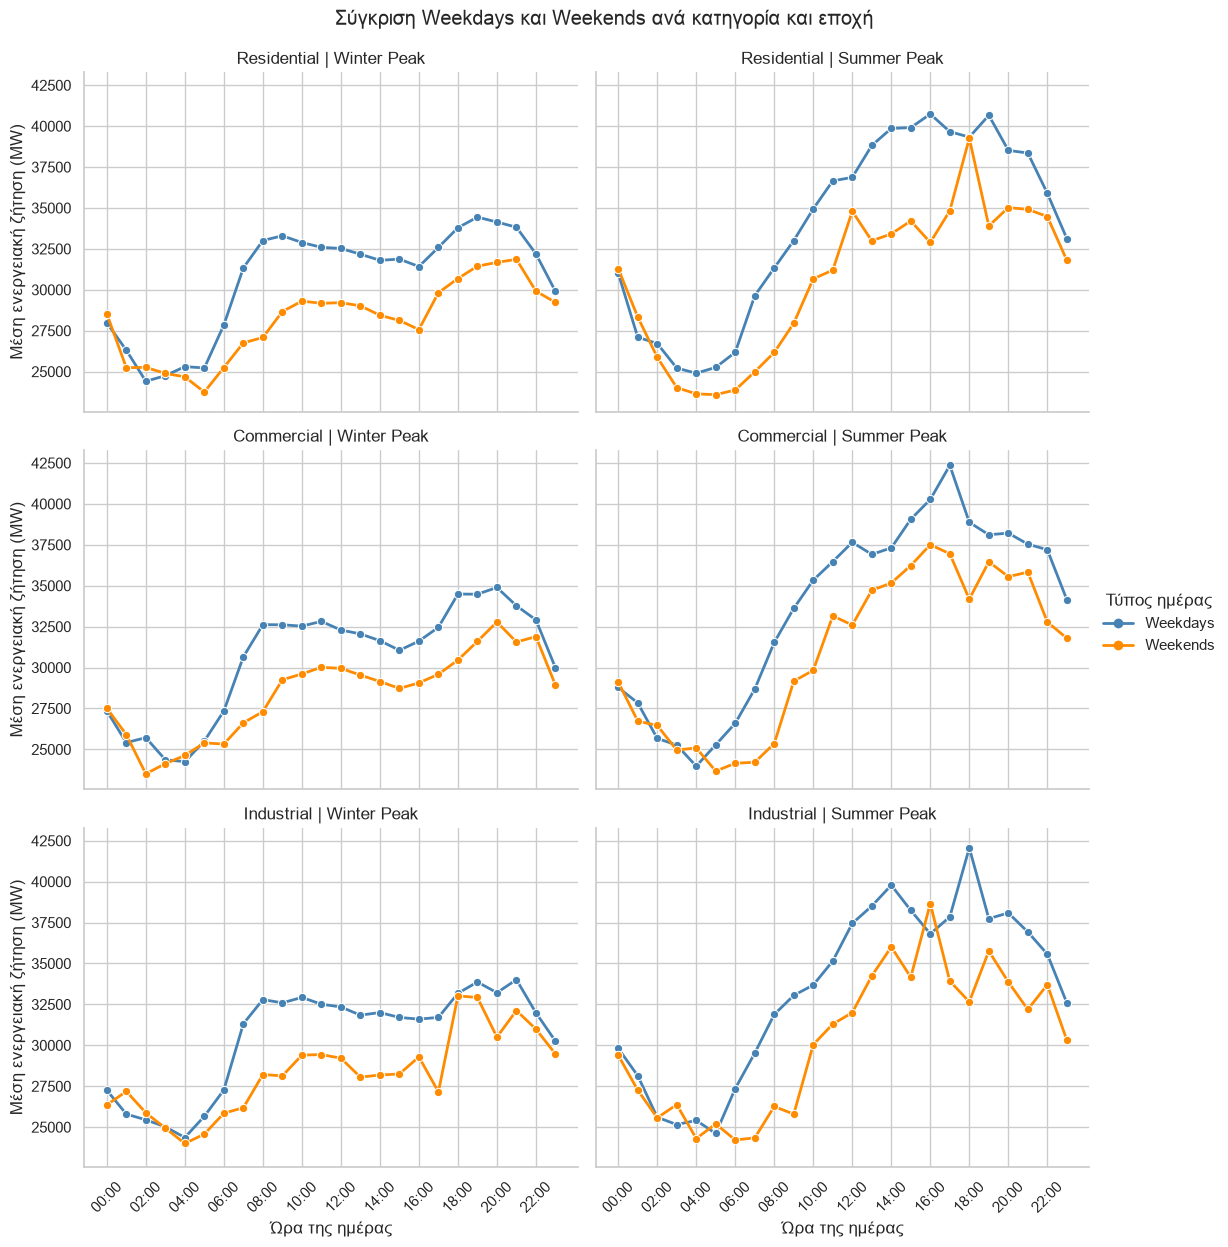

In [24]:
# Συγκρίνουμε Weekdays και Weekends
# για κάθε κατηγορία και κάθε εποχή
g = sns.relplot(
    data=rest_cycle_profile,
    x='Hour',
    y='PJME_MW',
    hue='Day_Type',
    hue_order=['Weekdays', 'Weekends'],
    row='Customer_Segment',
    row_order=[
        'Residential',
        'Commercial',
        'Industrial'
    ],
    col='Season',
    col_order=[
        'Winter Peak',
        'Summer Peak'
    ],
    kind='line',
    marker='o',
    linewidth=2,
    palette={
        'Weekdays': 'steelblue',
        'Weekends': 'darkorange'
    },
    height=4,
    aspect=1.4
)

g.set_axis_labels(
    'Ώρα της ημέρας',
    'Μέση ενεργειακή ζήτηση (MW)'
)

g.set_titles(
    row_template='{row_name}',
    col_template='{col_name}'
)

# Ρυθμίζουμε τον ωριαίο άξονα
for ax in g.axes.flat:
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels(
        [f'{hour:02d}:00' for hour in range(0, 24, 2)],
        rotation=45
    )

g._legend.set_title('Τύπος ημέρας')

g.fig.suptitle(
    'Σύγκριση Weekdays και Weekends ανά κατηγορία και εποχή',
    y=1.02
)

plt.show()

#### Αποτελέσματα της ανάλυσης εργάσιμων ημερών και Σαββατοκύριακου

Η σύγκριση δείχνει ότι η ενεργειακή ζήτηση είναι υψηλότερη τις εργάσιμες ημέρες και στις τρεις συνθετικές κατηγορίες πελατών.

Κατά τη διάρκεια της νύχτας, οι καμπύλες των Weekdays και των Weekends βρίσκονται σχετικά κοντά. Από τις πρωινές ώρες όμως, η ζήτηση των εργάσιμων ημερών αυξάνεται πιο έντονα και παραμένει υψηλότερη κατά το μεγαλύτερο μέρος της ημέρας. Η διαφορά γίνεται ιδιαίτερα εμφανής από το πρωί μέχρι τις απογευματινές και βραδινές ώρες.

Στη Summer Peak περίοδο η διαφορά είναι μεγαλύτερη. Η μέση ζήτηση των εργάσιμων ημερών είναι υψηλότερη από εκείνη των Σαββατοκύριακων κατά 9,27% στην Commercial, 10,50% στην Industrial και 10,82% στη Residential κατηγορία.

Στη Winter Peak περίοδο η διαφορά είναι μικρότερη, αλλά παραμένει ξεκάθαρη. Κυμαίνεται από 7,00% στην Commercial έως 8,81% στην Industrial κατηγορία.

Η μεγαλύτερη συνολική διαφορά εμφανίζεται στη Residential κατηγορία κατά τη Summer Peak και είναι 3.304,13 MW. Η μικρότερη εμφανίζεται στην Commercial κατηγορία κατά τη Winter Peak και είναι 1.999,72 MW.

Τα αποτελέσματα δείχνουν ότι η εβδομαδιαία ανθρώπινη δραστηριότητα συνδέεται με ουσιαστική μεταβολή του ημερήσιου φορτίου. Η χαμηλότερη ζήτηση τα Σαββατοκύριακα μπορεί να σχετίζεται με τον περιορισμό της επαγγελματικής, εμπορικής και βιομηχανικής δραστηριότητας.

Ορισμένες απότομες ωριαίες μεταβολές στις καμπύλες των Weekends πρέπει να ερμηνεύονται με προσοχή, επειδή οι παρατηρήσεις του Σαββατοκύριακου είναι λιγότερες.

Τέλος, οι κατηγορίες Residential, Commercial και Industrial είναι συνθετικές και δημιουργήθηκαν με τυχαία κατανομή. Επομένως, οι μικρές διαφορές μεταξύ τους δεν αποτελούν απόδειξη πραγματικής συμπεριφοράς αντίστοιχων πελατών. Το βασικό εύρημα που υποστηρίζεται από τα δεδομένα είναι η γενική διαφορά μεταξύ εργάσιμων ημερών και Σαββατοκύριακων.

## 7. Part 1b: Energy Consumption Prediction

### 7.1 Στρατηγική συγκέντρωσης και προετοιμασίας των δεδομένων

Για την ανακάλυψη φυσικών λειτουργικών προτύπων χρησιμοποιούμε ως μονάδα ανάλυσης μία πλήρη ημέρα. Κάθε ημέρα μετατρέπεται σε ένα προφίλ 24 ωριαίων τιμών ενεργειακής ζήτησης. Στο προφίλ προσθέτουμε επίσης τη μέση συνθετική θερμοκρασία και τα κυκλικά χαρακτηριστικά του μήνα.

Με αυτόν τον τρόπο, η ομαδοποίηση δεν βασίζεται μόνο σε μία μεμονωμένη μέτρηση, αλλά στη συνολική μορφή της ημερήσιας κατανάλωσης και στο εποχικό πλαίσιο κάθε ημέρας.

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Οι βιβλιοθήκες για μηχανική μάθηση φορτώθηκαν επιτυχώς.")

Οι βιβλιοθήκες για μηχανική μάθηση φορτώθηκαν επιτυχώς.


In [42]:
# Κρατάμε μόνο την ημερομηνία, χωρίς την ώρα
df['Date'] = df['Datetime'].dt.normalize()

# Μετατρέπουμε κάθε ημέρα σε ένα προφίλ 24 ωρών
daily_load_profiles = df.pivot_table(
    index='Date',
    columns='t_hour',
    values='PJME_MW',
    aggfunc='mean'
)

# Βάζουμε τις ώρες από 00:00 έως 23:00
daily_load_profiles = daily_load_profiles.reindex(
    columns=range(24)
)

# Δίνουμε κατανοητά ονόματα στις ωριαίες στήλες
daily_load_profiles.columns = [
    f'Hour_{hour:02d}' for hour in range(24)
]

# Κρατάμε μόνο τις ημέρες που έχουν και τις 24 ώρες
daily_load_profiles = daily_load_profiles.dropna()

# Υπολογίζουμε τα πρόσθετα χαρακτηριστικά κάθε ημέρας
daily_extra_features = (
    df.groupby('Date')
    .agg(
        Mean_Temperature=(
            'Synthetic_Temperature',
            'mean'
        ),
        Month_sin=(
            'Month_sin',
            'mean'
        ),
        Month_cos=(
            'Month_cos',
            'mean'
        )
    )
)

# Ενώνουμε τα ωριαία προφίλ με τα πρόσθετα χαρακτηριστικά
daily_profiles = daily_load_profiles.join(
    daily_extra_features,
    how='inner'
)

print(
    "Πλήρη ημερήσια προφίλ:",
    len(daily_profiles)
)

print(
    "Μεταβλητές που θα χρησιμοποιηθούν:",
    daily_profiles.shape[1]
)

print(
    "Ελλιπείς τιμές:",
    daily_profiles.isna().sum().sum()
)

daily_profiles.head()

Πλήρη ημερήσια προφίλ: 6027
Μεταβλητές που θα χρησιμοποιηθούν: 27
Ελλιπείς τιμές: 0


,Hour_00,Hour_01,Hour_02,Hour_03,Hour_04,Hour_05,Hour_06,Hour_07,Hour_08,Hour_09,Hour_10,Hour_11,Hour_12,Hour_13,Hour_14,Hour_15,Hour_16,Hour_17,Hour_18,Hour_19,Hour_20,Hour_21,Hour_22,Hour_23,Mean_Temperature,Month_sin,Month_cos
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,
2002-01-02,29563.0,28121.0,27437.0,27301.0,27533.0,28405.0,30748.0,34725.0,37313.0,37322.0,37035.0,36758.0,36284.0,35548.0,34978.0,34304.0,34169.0,35674.0,39532.0,40002.0,39484.0,38693.0,37016.0,34332.0,9.941485,1.5,1.732051
2002-01-03,31451.0,29414.0,28537.0,28118.0,28106.0,28650.0,30687.0,34696.0,37196.0,37436.0,37323.0,37198.0,36548.0,36024.0,35186.0,34478.0,34497.0,35807.0,39261.0,39662.0,39177.0,38328.0,36636.0,33869.0,9.843541,1.5,1.732051
2002-01-04,31038.0,29338.0,28421.0,28145.0,28122.0,28637.0,30540.0,34579.0,36958.0,36721.0,36318.0,35809.0,35333.0,34639.0,34237.0,33577.0,33352.0,34563.0,37710.0,38263.0,37539.0,36762.0,35368.0,33202.0,9.939907,1.5,1.732051
2002-01-05,30924.0,28635.0,27501.0,27034.0,26669.0,26822.0,27399.0,28557.0,29709.0,31241.0,32375.0,32490.0,31933.0,31099.0,30399.0,29551.0,29299.0,30729.0,33846.0,34092.0,33684.0,33033.0,32022.0,30680.0,9.660610,1.5,1.732051
2002-01-06,29011.0,27100.0,26097.0,25793.0,25657.0,25778.0,26396.0,27143.0,28059.0,29379.0,30744.0,31051.0,31040.0,31139.0,31233.0,31375.0,32003.0,33899.0,35900.0,35971.0,35306.0,34315.0,32731.0,30646.0,10.075497,1.5,1.732051


### 7.2 Automated Profile Grouping — Αυτόματη ομαδοποίηση προφίλ

### 7.2.1 Τυποποίηση των μεταβλητών

Οι μεταβλητές που θα χρησιμοποιήσουμε στο clustering δεν βρίσκονται στην ίδια αριθμητική κλίμακα. Για παράδειγμα, οι τιμές του `PJME_MW` είναι πολύ μεγαλύτερες από τις τιμές της συνθετικής θερμοκρασίας και των `Month_sin` και `Month_cos`.

Το K-Means δημιουργεί τις ομάδες υπολογίζοντας αποστάσεις. Αν χρησιμοποιούσαμε τις αρχικές τιμές, οι μεταβλητές με τους μεγαλύτερους αριθμούς θα επηρέαζαν περισσότερο το αποτέλεσμα.

Για να το αποφύγουμε, εφαρμόζουμε τυποποίηση με το `StandardScaler`. Μετά την τυποποίηση, κάθε μεταβλητή έχει περίπου μέση τιμή 0 και τυπική απόκλιση 1.

Η διαδικασία αυτή δεν αλλάζει τη μορφή των δεδομένων. Απλώς τα μεταφέρει σε μια κοινή κλίμακα, ώστε όλες οι μεταβλητές να μπορούν να συμμετέχουν πιο ισότιμα στη δημιουργία των clusters.

In [57]:
# Κρατάμε τις μεταβλητές που θα χρησιμοποιηθούν
# για τη δημιουργία των clusters
X = daily_profiles.copy()

# Δημιουργούμε τον scaler
scaler = StandardScaler()

# Τυποποιούμε τις μεταβλητές
X_scaled = scaler.fit_transform(X)

# Ελέγχουμε ότι οι διαστάσεις δεν άλλαξαν
print(
    "Διαστάσεις πριν την τυποποίηση:",
    X.shape
)

print(
    "Διαστάσεις μετά την τυποποίηση:",
    X_scaled.shape
)

# Ελέγχουμε τη νέα αριθμητική κλίμακα
print(
    "Μέση τιμή μετά την τυποποίηση:",
    round(X_scaled.mean(), 4)
)

print(
    "Τυπική απόκλιση μετά την τυποποίηση:",
    round(X_scaled.std(), 4)
)

Διαστάσεις πριν την τυποποίηση: (6027, 27)
Διαστάσεις μετά την τυποποίηση: (6027, 27)
Μέση τιμή μετά την τυποποίηση: -0.0
Τυπική απόκλιση μετά την τυποποίηση: 1.0


### 7.2.2 Επιλογή του αριθμού των clusters

Δεν γνωρίζουμε από πριν πόσες φυσικές ομάδες υπάρχουν στα ημερήσια προφίλ. Για τον λόγο αυτό δοκιμάζουμε διαφορετικές τιμές του `k`, από 2 έως 8 clusters.

Για να επιλέξουμε τον πιο λογικό αριθμό ομάδων χρησιμοποιούμε δύο μεθόδους:

- **Elbow Method:** εξετάζει πόσο μειώνεται η απόσταση των παρατηρήσεων από το κέντρο του cluster στο οποίο ανήκουν. Αναζητούμε το σημείο όπου η βελτίωση αρχίζει να γίνεται λιγότερο έντονη.
- **Silhouette Score:** δείχνει πόσο καλά διαχωρίζονται τα clusters μεταξύ τους. Μια μεγαλύτερη τιμή συνήθως δείχνει πιο ξεκάθαρες ομάδες.

Η τελική επιλογή του `k` θα βασιστεί στον συνδυασμό των δύο αποτελεσμάτων και όχι σε μια αυθαίρετη απόφαση.

In [44]:
# Δοκιμάζουμε από 2 έως 8 clusters
k_values = range(2, 9)

inertia_values = []
silhouette_values = []

for k in k_values:

    # Δημιουργούμε ένα μοντέλο για κάθε αριθμό clusters
    model = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=student_id
    )

    # Εκπαιδεύουμε το μοντέλο
    cluster_labels = model.fit_predict(
        X_scaled
    )

    # Αποθηκεύουμε την inertia
    inertia_values.append(
        model.inertia_
    )

    # Υπολογίζουμε το Silhouette Score
    silhouette = silhouette_score(
        X_scaled,
        cluster_labels,
        sample_size=3000,
        random_state=student_id
    )

    silhouette_values.append(
        silhouette
    )

# Δημιουργούμε έναν πίνακα με τα αποτελέσματα
clustering_evaluation = pd.DataFrame({
    'k': list(k_values),
    'Inertia': inertia_values,
    'Silhouette_Score': silhouette_values
})

clustering_evaluation.round(4)

,k,Inertia,Silhouette_Score
0,2,81606.7967,0.4221
1,3,60769.6674,0.3249
2,4,50550.6190,0.3471
3,5,42583.7125,0.3067
4,6,36755.0024,0.3119
5,7,32661.2228,0.3037
6,8,29011.1582,0.3002


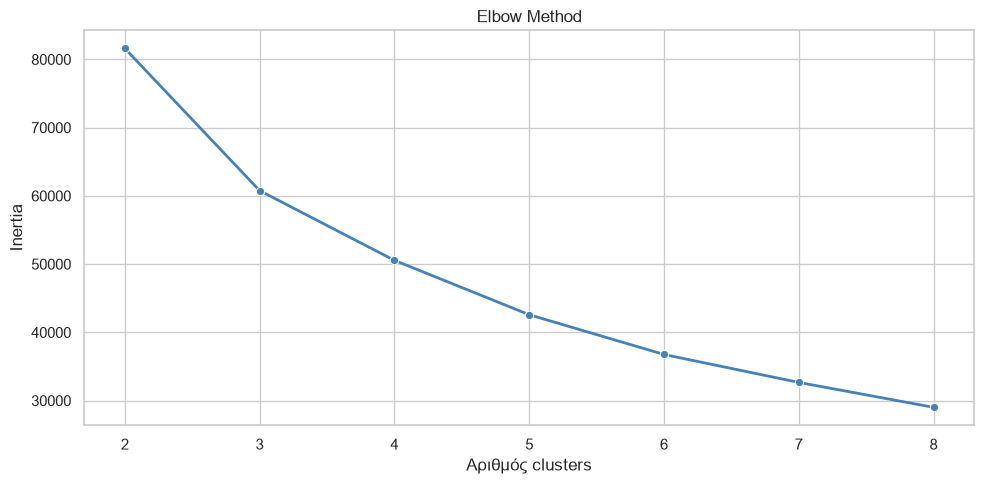

In [45]:
# Δημιουργούμε το διάγραμμα Elbow Method
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=clustering_evaluation,
    x='k',
    y='Inertia',
    marker='o',
    linewidth=2,
    color='steelblue'
)

plt.title('Elbow Method')
plt.xlabel('Αριθμός clusters')
plt.ylabel('Inertia')
plt.xticks(list(k_values))

plt.tight_layout()
plt.show()

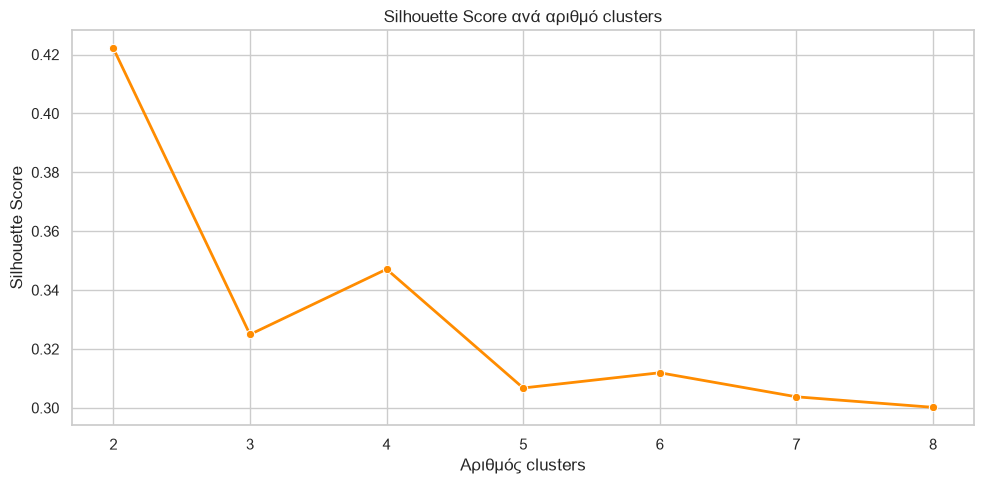

In [46]:
# Δημιουργούμε το διάγραμμα Silhouette Score
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=clustering_evaluation,
    x='k',
    y='Silhouette_Score',
    marker='o',
    linewidth=2,
    color='darkorange'
)

plt.title('Silhouette Score ανά αριθμό clusters')
plt.xlabel('Αριθμός clusters')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_values))

plt.tight_layout()
plt.show()

#### Αποτελέσματα επιλογής αριθμού clusters

Η Inertia μειώνεται όσο αυξάνεται ο αριθμός των clusters. Αυτό είναι αναμενόμενο, επειδή οι περισσότερες ομάδες μπορούν να προσαρμοστούν καλύτερα στα δεδομένα. Ωστόσο, μετά τις πρώτες τιμές του `k`, η βελτίωση γίνεται σταδιακά μικρότερη.

Το υψηλότερο Silhouette Score εμφανίζεται στα 2 clusters και είναι 0,4221. Αυτό σημαίνει ότι, από τις επιλογές που εξετάσαμε, τα δύο clusters δημιουργούν τον πιο καθαρό διαχωρισμό των ημερήσιων προφίλ.

Στα 4 clusters εμφανίζεται επίσης μια σχετικά καλή τιμή, αλλά το Silhouette Score είναι χαμηλότερο και η λύση γίνεται πιο σύνθετη.

Για τον λόγο αυτό επιλέγουμε `k = 2`. Η επιλογή βασίζεται στα αποτελέσματα των δεδομένων και κυρίως στο υψηλότερο Silhouette Score, όχι σε έναν αριθμό ομάδων που αποφασίστηκε από πριν.

Στο επόμενο στάδιο θα εξετάσουμε τα χαρακτηριστικά των δύο clusters, ώστε να καταλάβουμε τι είδους λειτουργική κατάσταση αντιπροσωπεύει το καθένα.

### 7.2.3 Τελική εφαρμογή του K-Means

Με βάση τα αποτελέσματα του Elbow Method και του Silhouette Score, εφαρμόζουμε το τελικό K-Means με δύο clusters.

Ο αλγόριθμος αντιστοιχίζει κάθε ημερήσιο προφίλ σε μία από τις δύο ομάδες. Οι αριθμοί `0` και `1` είναι απλές ετικέτες και δεν έχουν ακόμη κάποια λειτουργική σημασία.

Για να καταλάβουμε τι αντιπροσωπεύει κάθε cluster, πρέπει πρώτα να εξετάσουμε τα χαρακτηριστικά της ενεργειακής ζήτησης των ημερών που περιλαμβάνει.

In [47]:
# Επιλέγουμε αυτόματα το k
# με το υψηλότερο Silhouette Score
best_result = clustering_evaluation.loc[
    clustering_evaluation['Silhouette_Score'].idxmax()
]

optimal_k = int(
    best_result['k']
)

print(
    "Επιλεγμένος αριθμός clusters:",
    optimal_k
)

# Δημιουργούμε το τελικό μοντέλο
final_kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    n_init=10,
    random_state=student_id
)

# Αντιστοιχίζουμε κάθε ημέρα σε ένα cluster
final_cluster_labels = final_kmeans.fit_predict(
    X_scaled
)

# Προσθέτουμε το cluster στα ημερήσια προφίλ
daily_clustered = daily_profiles.copy()

daily_clustered['Cluster'] = (
    final_cluster_labels
)

# Μετράμε τις ημέρες κάθε cluster
cluster_counts = (
    daily_clustered['Cluster']
    .value_counts()
    .sort_index()
)

# Υπολογίζουμε το ποσοστό κάθε cluster
cluster_percentages = (
    daily_clustered['Cluster']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("\nΚατανομή ημερών ανά cluster:")

for cluster in cluster_counts.index:
    print(
        f"Cluster {cluster}: "
        f"{cluster_counts[cluster]} ημέρες "
        f"({cluster_percentages[cluster]:.1f}%)"
    )

Επιλεγμένος αριθμός clusters: 2

Κατανομή ημερών ανά cluster:
Cluster 0: 2162 ημέρες (35.9%)
Cluster 1: 3865 ημέρες (64.1%)


#### Αποτέλεσμα της τελικής ομαδοποίησης

Ο K-Means χώρισε τα 6.027 ημερήσια προφίλ σε δύο ομάδες.

Το Cluster 0 περιλαμβάνει 2.162 ημέρες, δηλαδή το 35,9% του dataset, ενώ το Cluster 1 περιλαμβάνει 3.865 ημέρες, δηλαδή το 64,1%.

Οι αριθμοί των clusters δεν δείχνουν αν μια ομάδα έχει χαμηλή ή υψηλή κατανάλωση. Για να καταλάβουμε τι αντιπροσωπεύει κάθε cluster, πρέπει να εξετάσουμε τα επίπεδα ζήτησης, τη μεταβλητότητα, τις αιχμές και τη συνθετική θερμοκρασία των ημερών που περιλαμβάνει.

### 7.3 Team Characteristic Diagnostic

Σε αυτό το στάδιο εξετάζουμε τα δύο clusters, ώστε να καταλάβουμε τι είδους λειτουργική κατάσταση αντιπροσωπεύει το καθένα.

Για κάθε ημέρα υπολογίζουμε τη μέση και τη διάμεση ζήτηση, την ημερήσια μεταβλητότητα, την ελάχιστη και τη μέγιστη τιμή, το εύρος της ζήτησης και την ώρα αιχμής. Εξετάζουμε επίσης τη μέση συνθετική θερμοκρασία και τα απόλυτα άκρα της ζήτησης που εμφανίζονται σε κάθε cluster.

Στη συνέχεια συγκρίνουμε αυτά τα χαρακτηριστικά μεταξύ των δύο clusters. Με βάση τα αποτελέσματα, ξεχωρίζουμε το συνηθισμένο μοτίβο λειτουργίας από τις ημέρες κατά τις οποίες το δίκτυο παρουσιάζει υψηλότερη ζήτηση και μεγαλύτερη μεταβλητότητα.

In [48]:
# Οι 24 ωριαίες στήλες της κατανάλωσης
hour_columns = [
    f'Hour_{hour:02d}' for hour in range(24)
]

# Δημιουργούμε έναν νέο πίνακα για τη διάγνωση
daily_diagnostics = daily_clustered.copy()

# Υπολογίζουμε τα βασικά χαρακτηριστικά κάθε ημέρας
daily_diagnostics['Mean_Demand'] = (
    daily_diagnostics[hour_columns].mean(axis=1)
)

daily_diagnostics['Median_Demand'] = (
    daily_diagnostics[hour_columns].median(axis=1)
)

daily_diagnostics['Daily_Volatility'] = (
    daily_diagnostics[hour_columns].std(axis=1)
)

daily_diagnostics['Daily_Minimum'] = (
    daily_diagnostics[hour_columns].min(axis=1)
)

daily_diagnostics['Daily_Maximum'] = (
    daily_diagnostics[hour_columns].max(axis=1)
)

daily_diagnostics['Daily_Range'] = (
    daily_diagnostics['Daily_Maximum']
    - daily_diagnostics['Daily_Minimum']
)

# Βρίσκουμε την ώρα αιχμής κάθε ημέρας
daily_diagnostics['Peak_Hour'] = (
    daily_diagnostics[hour_columns]
    .idxmax(axis=1)
    .str.replace('Hour_', '')
    .astype(int)
)

# Συγκεντρώνουμε τα χαρακτηριστικά ανά cluster
cluster_diagnostics = (
    daily_diagnostics
    .groupby('Cluster')
    .agg(
        Days=('Mean_Demand', 'size'),
        Mean_Demand=('Mean_Demand', 'mean'),
        Median_Demand=('Median_Demand', 'mean'),
        Average_Volatility=('Daily_Volatility', 'mean'),
        Average_Daily_Minimum=('Daily_Minimum', 'mean'),
        Average_Daily_Maximum=('Daily_Maximum', 'mean'),
        Average_Daily_Range=('Daily_Range', 'mean'),
        Absolute_Minimum=('Daily_Minimum', 'min'),
        Absolute_Maximum=('Daily_Maximum', 'max'),
        Mean_Temperature=('Mean_Temperature', 'mean')
    )
)

# Βρίσκουμε τη συχνότερη ώρα αιχμής κάθε cluster
most_common_peak_hour = (
    daily_diagnostics
    .groupby('Cluster')['Peak_Hour']
    .agg(lambda values: values.mode().iloc[0])
)

cluster_diagnostics['Most_Common_Peak_Hour'] = (
    most_common_peak_hour
)

cluster_diagnostics.round(2)

,Days,Mean_Demand,Median_Demand,Average_Volatility,Average_Daily_Minimum,Average_Daily_Maximum,Average_Daily_Range,Absolute_Minimum,Absolute_Maximum,Mean_Temperature,Most_Common_Peak_Hour
Cluster,,,,,,,,,,,
0,2162,37212.98,38351.91,5370.64,28873.31,44187.77,15314.46,22364.0,62009.0,17.13,17
1,3865,29243.02,30475.47,3567.44,23335.09,33727.80,10392.70,14544.0,43260.0,15.19,19


#### Ερμηνεία των χαρακτηριστικών των clusters

Το Cluster 0 περιλαμβάνει 2.162 ημέρες και παρουσιάζει σαφώς υψηλότερη ενεργειακή ζήτηση. Η μέση ημερήσια ζήτηση φτάνει τα 37.212,98 MW, ενώ η μέση ημερήσια μέγιστη τιμή είναι 44.187,77 MW.

Παράλληλα, το Cluster 0 παρουσιάζει μεγαλύτερη μεταβλητότητα και μεγαλύτερο ημερήσιο εύρος. Η μέση μεταβλητότητα είναι 5.370,64 MW και το μέσο ημερήσιο εύρος φτάνει τα 15.314,46 MW. Η συχνότερη ώρα αιχμής είναι στις `17:00`.

Το Cluster 1 περιλαμβάνει 3.865 ημέρες και έχει χαμηλότερο και πιο σταθερό προφίλ. Η μέση ζήτηση είναι 29.243,02 MW και η μέση ημερήσια μέγιστη τιμή είναι 33.727,80 MW. Η μεταβλητότητα και το ημερήσιο εύρος είναι επίσης χαμηλότερα, ενώ η συχνότερη ώρα αιχμής είναι στις `19:00`.

Η μέση ζήτηση του Cluster 0 είναι περίπου 7.970 MW υψηλότερη από εκείνη του Cluster 1. Επίσης, η μεγαλύτερη τιμή που καταγράφεται στο Cluster 0 φτάνει τα 62.009 MW, ενώ στο Cluster 1 δεν ξεπερνά τα 43.260 MW.

Με βάση αυτά τα χαρακτηριστικά, το Cluster 1 περιγράφει την πιο συνηθισμένη και σταθερή κατάσταση του δικτύου και χαρακτηρίζεται ως **Normal Operation**. Το Cluster 0 περιλαμβάνει ημέρες με υψηλότερη ζήτηση, μεγαλύτερες διακυμάνσεις και εντονότερες αιχμές και χαρακτηρίζεται ως **Critical System Strain**.

Οι χαρακτηρισμοί αυτοί είναι σχετικοί με τα μοτίβα του dataset και δεν αποτελούν πραγματικά όρια ασφαλείας ή επίσημες προειδοποιήσεις του δικτύου.

Το Cluster 0 παρουσιάζει επίσης υψηλότερη μέση συνθετική θερμοκρασία. Ωστόσο, η θερμοκρασία είναι τεχνητά δημιουργημένη και δεν πρέπει να παρουσιαστεί ως πραγματική μετεωρολογική μέτρηση ή ως απόδειξη ότι προκάλεσε την αυξημένη ζήτηση.

In [49]:
# Δίνουμε ένα λειτουργικό όνομα σε κάθε cluster
cluster_names = {
    0: 'Critical System Strain',
    1: 'Normal Operation'
}

daily_clustered['Operational_State'] = (
    daily_clustered['Cluster'].map(cluster_names)
)

daily_diagnostics['Operational_State'] = (
    daily_diagnostics['Cluster'].map(cluster_names)
)

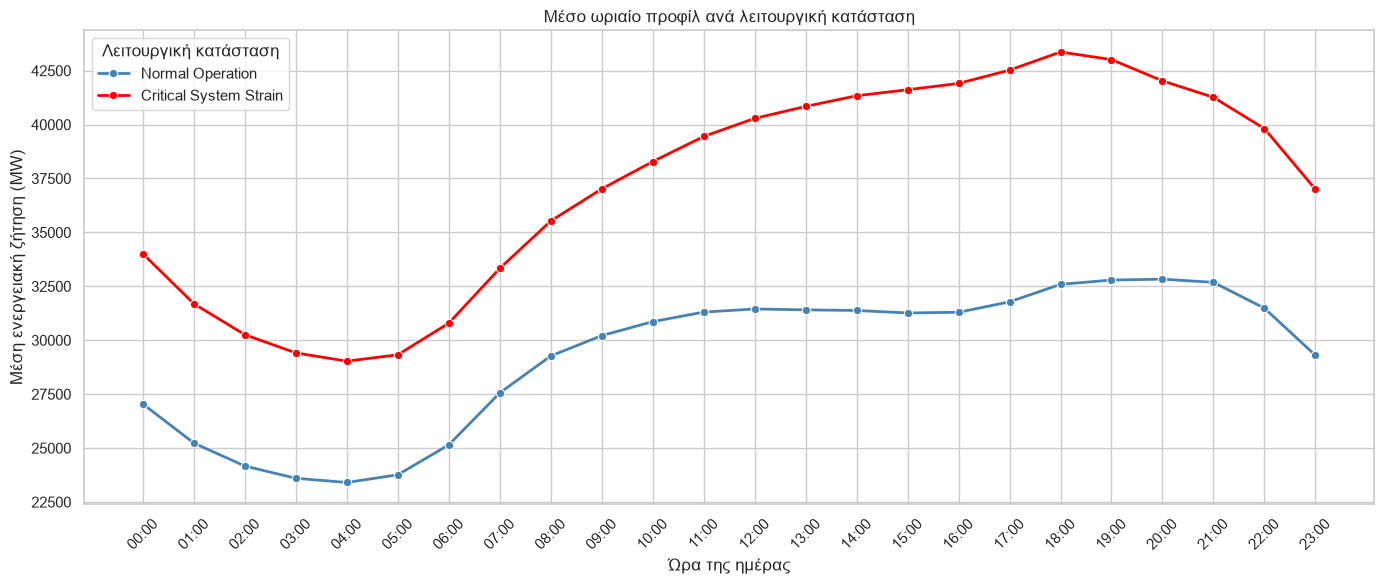

In [50]:
# Υπολογίζουμε τη μέση ζήτηση ανά ώρα και cluster
cluster_hourly_profile = (
    daily_clustered
    .groupby('Cluster')[hour_columns]
    .mean()
    .T
    .reset_index()
    .rename(columns={'index': 'Hour_Label'})
)

# Μετατρέπουμε την ώρα σε αριθμό
cluster_hourly_profile['Hour'] = (
    cluster_hourly_profile['Hour_Label']
    .str.replace('Hour_', '')
    .astype(int)
)

# Μετατρέπουμε τον πίνακα σε μορφή κατάλληλη για Seaborn
cluster_hourly_long = cluster_hourly_profile.melt(
    id_vars=['Hour_Label', 'Hour'],
    value_vars=[0, 1],
    var_name='Cluster',
    value_name='Mean_Demand'
)

# Προσθέτουμε τα λειτουργικά ονόματα
cluster_hourly_long['Operational_State'] = (
    cluster_hourly_long['Cluster'].map(cluster_names)
)

# Δημιουργούμε το συγκριτικό διάγραμμα
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=cluster_hourly_long,
    x='Hour',
    y='Mean_Demand',
    hue='Operational_State',
    hue_order=[
        'Normal Operation',
        'Critical System Strain'
    ],
    palette={
        'Normal Operation': 'steelblue',
        'Critical System Strain': 'red'
    },
    marker='o',
    linewidth=2
)

plt.title('Μέσο ωριαίο προφίλ ανά λειτουργική κατάσταση')
plt.xlabel('Ώρα της ημέρας')
plt.ylabel('Μέση ενεργειακή ζήτηση (MW)')

plt.xticks(
    range(24),
    [f'{hour:02d}:00' for hour in range(24)],
    rotation=45
)

plt.legend(title='Λειτουργική κατάσταση')
plt.tight_layout()
plt.show()

#### Ερμηνεία του ωριαίου προφίλ των clusters

Το πρώτο που ξεχωρίζει στο διάγραμμα είναι ότι οι δύο καμπύλες έχουν παρόμοια μορφή, αλλά βρίσκονται σε διαφορετικά επίπεδα ζήτησης.

Και στις δύο περιπτώσεις, η κατανάλωση μειώνεται κατά τη διάρκεια της νύχτας και φτάνει στο χαμηλότερο σημείο της περίπου στις `04:00`. Στη συνέχεια αρχίζει να ανεβαίνει, καθώς ξεκινά η καθημερινή δραστηριότητα.

Στο **Critical System Strain**, η ζήτηση παραμένει αισθητά υψηλότερη σε όλες τις ώρες. Η πρωινή άνοδος είναι έντονη και η κατανάλωση συνεχίζει να αυξάνεται μέχρι αργά το απόγευμα, με τη μέση καμπύλη να φτάνει στην κορυφή της περίπου στις `18:00`.

Στο **Normal Operation**, η ζήτηση είναι χαμηλότερη και πιο σταθερή. Μετά την πρωινή αύξηση, παραμένει σχετικά σταθερή για αρκετές ώρες και παρουσιάζει μια μικρότερη βραδινή αιχμή περίπου στις `19:00–20:00`.

Στον προηγούμενο πίνακα, η συχνότερη ώρα αιχμής ήταν `17:00` για το Critical System Strain και `19:00` για το Normal Operation. Η μικρή διαφορά με το γράφημα είναι φυσιολογική: ο πίνακας δείχνει ποια ώρα εμφανίζεται συχνότερα ως αιχμή στις ξεχωριστές ημέρες, ενώ το γράφημα δείχνει τη μέση ζήτηση όλων των ημερών ανά ώρα.

Με βάση τα αποτελέσματα, το Cluster 0 αντιπροσωπεύει ημέρες με υψηλότερη ζήτηση και μεγαλύτερη πίεση στο δίκτυο. Το Cluster 1 αντιπροσωπεύει πιο συνηθισμένες ημέρες, με χαμηλότερη και πιο σταθερή κατανάλωση.

Οι δύο ονομασίες χρησιμοποιούνται μόνο για να περιγράψουν τα μοτίβα του συγκεκριμένου dataset. Δεν αποτελούν πραγματικές προειδοποιήσεις ή επίσημα όρια ασφαλείας του δικτύου.

### 7.4 Client Mapping & Impact

Στο τελευταίο στάδιο εξετάζουμε πώς κατανέμονται οι τρεις συνθετικές κατηγορίες πελατών στα δύο clusters.

Κάθε ημερομηνία έχει ήδη αντιστοιχιστεί σε μία λειτουργική κατάσταση. Συνδέουμε αυτή την πληροφορία με τις αρχικές ωριαίες παρατηρήσεις, ώστε να εξετάσουμε τη συμπεριφορά κάθε κατηγορίας πελατών στις καταστάσεις `Normal Operation` και `Critical System Strain`.

Συγκεκριμένα, εξετάζουμε:

- πώς κατανέμονται οι παρατηρήσεις κάθε πελάτη μεταξύ των δύο λειτουργικών καταστάσεων,
- ποια είναι η σύνθεση κάθε λειτουργικής κατάστασης από παρατηρήσεις των `Commercial Hub`, `Residential District` και `Industrial Complex`,
- πώς αλλάζει η μέση ενεργειακή ζήτηση κάθε πελάτη μεταξύ κανονικής λειτουργίας και αυξημένης πίεσης του συστήματος.

In [51]:
# Κρατάμε την ημερομηνία, το cluster
# και τη λειτουργική κατάσταση κάθε ημέρας
cluster_mapping = (
    daily_clustered[
        ['Cluster', 'Operational_State']
    ]
    .reset_index()
)

# Συνδέουμε τα ημερήσια clusters
# με τις αρχικές ωριαίες παρατηρήσεις
client_cluster_data = df[
    ['Date', 'Customer_Segment', 'PJME_MW']
].merge(
    cluster_mapping,
    on='Date',
    how='inner'
)

# Δίνουμε πιο περιγραφικά ονόματα στους πελάτες
client_names = {
    'Commercial': 'Commercial Hub',
    'Residential': 'Residential District',
    'Industrial': 'Industrial Complex'
}

client_cluster_data['Client'] = (
    client_cluster_data['Customer_Segment']
    .map(client_names)
)

print(
    "Ωριαίες παρατηρήσεις που αντιστοιχίστηκαν:",
    len(client_cluster_data)
)

client_cluster_data.head()

Ωριαίες παρατηρήσεις που αντιστοιχίστηκαν: 144652


,Date,Customer_Segment,PJME_MW,Cluster,Operational_State,Client
0,2002-01-02,Residential,29563.0,0,Critical System Strain,Residential District
1,2002-01-02,Commercial,28121.0,0,Critical System Strain,Commercial Hub
2,2002-01-02,Residential,27437.0,0,Critical System Strain,Residential District
3,2002-01-02,Commercial,27301.0,0,Critical System Strain,Commercial Hub
4,2002-01-02,Residential,27533.0,0,Critical System Strain,Residential District


In [52]:
# Υπολογίζουμε το ποσοστό των παρατηρήσεων
# κάθε πελάτη στις δύο λειτουργικές καταστάσεις
client_distribution = (
    pd.crosstab(
        client_cluster_data['Client'],
        client_cluster_data['Operational_State'],
        normalize='index'
    )
    * 100
)

client_distribution.round(2)

Operational_State,Critical System Strain,Normal Operation
Client,,
Commercial Hub,35.90,64.10
Industrial Complex,35.85,64.15
Residential District,35.86,64.14


In [53]:
# Εξετάζουμε ποιοι πελάτες αποτελούν
# κάθε λειτουργική κατάσταση
state_composition = (
    pd.crosstab(
        client_cluster_data['Operational_State'],
        client_cluster_data['Client'],
        normalize='index'
    )
    * 100
)

state_composition.round(2)

Client,Commercial Hub,Industrial Complex,Residential District
Operational_State,,,
Critical System Strain,34.93,25.12,39.96
Normal Operation,34.88,25.15,39.97


In [54]:
# Υπολογίζουμε τη μέση ζήτηση κάθε πελάτη
# στις δύο λειτουργικές καταστάσεις
client_demand_impact = (
    client_cluster_data
    .pivot_table(
        index='Client',
        columns='Operational_State',
        values='PJME_MW',
        aggfunc='mean'
    )
)

# Υπολογίζουμε τη διαφορά της ζήτησης
client_demand_impact['Difference_MW'] = (
    client_demand_impact['Critical System Strain']
    - client_demand_impact['Normal Operation']
)

client_demand_impact['Difference_Percentage'] = (
    client_demand_impact['Difference_MW']
    / client_demand_impact['Normal Operation']
    * 100
)

client_demand_impact.round(2)

Operational_State,Critical System Strain,Normal Operation,Difference_MW,Difference_Percentage
Client,,,,
Commercial Hub,37256.97,29233.91,8023.07,27.44
Industrial Complex,37173.05,29274.41,7898.65,26.98
Residential District,37199.62,29230.43,7969.19,27.26


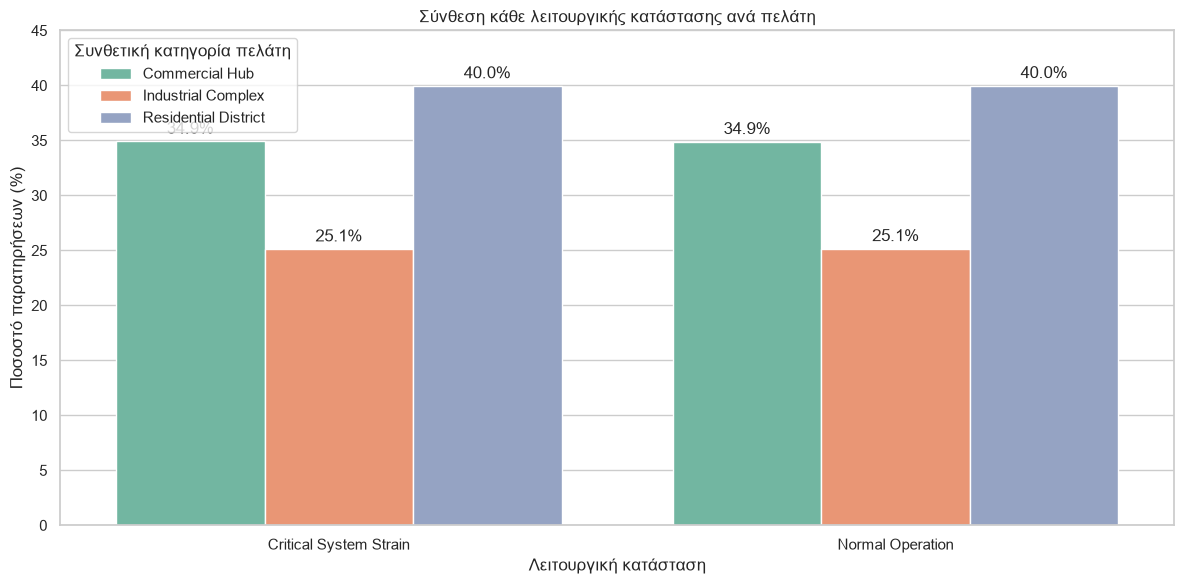

In [55]:
# Μετατρέπουμε τον πίνακα σε μορφή κατάλληλη για Seaborn
state_composition_long = (
    state_composition
    .reset_index()
    .melt(
        id_vars='Operational_State',
        var_name='Client',
        value_name='Percentage'
    )
)

# Δημιουργούμε το διάγραμμα
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=state_composition_long,
    x='Operational_State',
    y='Percentage',
    hue='Client',
    palette='Set2'
)

plt.title('Σύνθεση κάθε λειτουργικής κατάστασης ανά πελάτη')
plt.xlabel('Λειτουργική κατάσταση')
plt.ylabel('Ποσοστό παρατηρήσεων (%)')
plt.ylim(0, 45)

# Εμφανίζουμε τα ποσοστά πάνω στις μπάρες
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.legend(title='Συνθετική κατηγορία πελάτη')
plt.tight_layout()
plt.show()

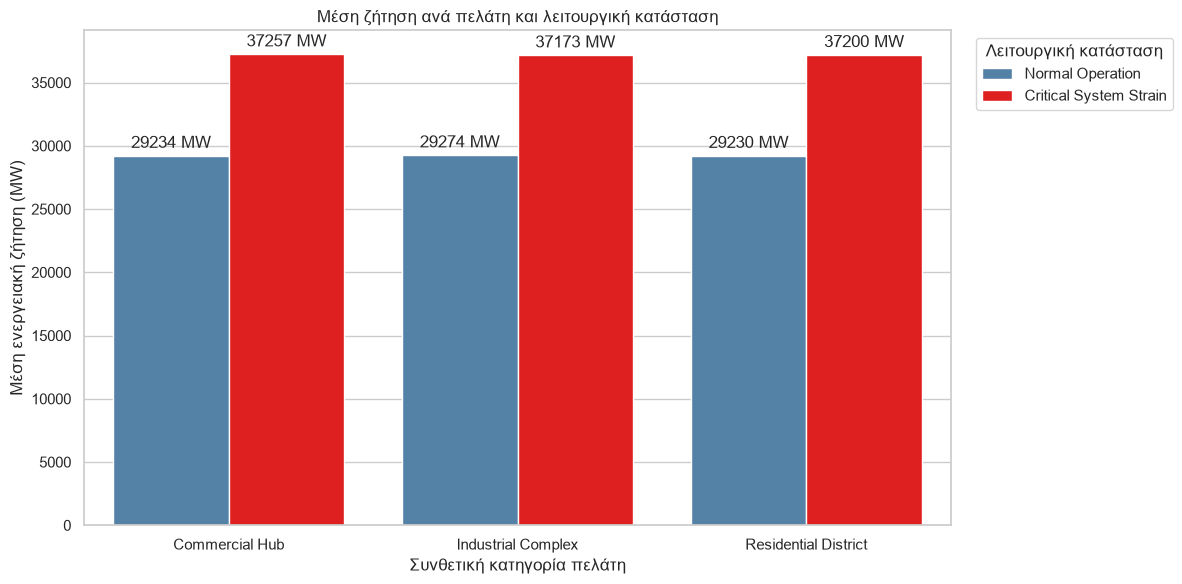

In [56]:
# Κρατάμε τις μέσες τιμές ζήτησης
client_demand_long = (
    client_demand_impact[
        [
            'Normal Operation',
            'Critical System Strain'
        ]
    ]
    .reset_index()
    .melt(
        id_vars='Client',
        var_name='Operational_State',
        value_name='Mean_Demand'
    )
)

# Δημιουργούμε το συγκριτικό γράφημα
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=client_demand_long,
    x='Client',
    y='Mean_Demand',
    hue='Operational_State',
    hue_order=[
        'Normal Operation',
        'Critical System Strain'
    ],
    palette={
        'Normal Operation': 'steelblue',
        'Critical System Strain': 'red'
    }
)

plt.title('Μέση ζήτηση ανά πελάτη και λειτουργική κατάσταση')
plt.xlabel('Συνθετική κατηγορία πελάτη')
plt.ylabel('Μέση ενεργειακή ζήτηση (MW)')

# Εμφανίζουμε τις τιμές πάνω στις μπάρες
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f MW',
        padding=3
    )

plt.legend(
    title='Λειτουργική κατάσταση',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

#### Ερμηνεία της κατανομής και της επίδρασης των πελατών

Το πρώτο γράφημα έδειξε ότι η σύνθεση των δύο λειτουργικών καταστάσεων είναι σχεδόν ίδια. Το Residential District αντιπροσωπεύει περίπου το 40% των παρατηρήσεων, το Commercial Hub περίπου το 35% και το Industrial Complex περίπου το 25%.

Αυτό σημαίνει ότι κανένας συνθετικός πελάτης δεν εμφανίζεται περισσότερο στο Critical System Strain. Οι αναλογίες παραμένουν κοντά στα αρχικά ποσοστά που χρησιμοποιήθηκαν για την τυχαία δημιουργία της `Customer_Segment`.

Το δεύτερο γράφημα δείχνει όμως ότι η λειτουργική κατάσταση επηρεάζει ξεκάθαρα το επίπεδο της ζήτησης. Στο Normal Operation, η μέση ζήτηση είναι περίπου 29.200 MW και για τους τρεις πελάτες. Στο Critical System Strain αυξάνεται περίπου στα 37.200 MW.

Η μεγαλύτερη αύξηση εμφανίζεται στο Commercial Hub και είναι 8.023,07 MW ή 27,44%. Αντίστοιχα, η αύξηση είναι 7.898,65 MW για το Industrial Complex και 7.969,19 MW για το Residential District.

Οι διαφορές μεταξύ των τριών πελατών είναι πολύ μικρές. Επομένως, δεν φαίνεται κάποια συγκεκριμένη κατηγορία να οδηγεί από μόνη της την κατάσταση αυξημένης πίεσης. Το Critical System Strain περιγράφει περισσότερο μια γενική κατάσταση υψηλής ζήτησης που επηρεάζει όλες τις κατηγορίες με παρόμοιο τρόπο.

Το αποτέλεσμα είναι αναμενόμενο, επειδή οι κατηγορίες πελατών δημιουργήθηκαν τυχαία και δεν βασίζονται σε πραγματικές καταναλωτικές συμπεριφορές. Για αυτόν τον λόγο δεν μπορούμε να χρησιμοποιήσουμε τις μικρές διαφορές για να βγάλουμε πραγματικά συμπεράσματα για οικιακούς, εμπορικούς ή βιομηχανικούς πελάτες.